# Plotting the Data

In [1]:
# Import necessary packages

# General utilities
import warnings

# Data handling and analysis
import numpy as np
from multiprocessing import Pool, Array
import pandas as pd

# Visualization
import altair as alt
alt.data_transformers.enable("vegafusion")

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

sns.set()
sns.set_style("ticks")
warnings.filterwarnings('ignore')

In [38]:
domain = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
LCZ_hex =  ['#FFFFFF',
    '#910613', '#D9081C', '#FF0A22', '#C54F1E', '#FF6628',
    '#FF985E', '#FDED3F', '#BBBBBB', '#FFCBAB', '#565656',
    '#006A18', '#00A926', '#628432', '#B5DA7F', '#000000',
    '#FCF7B1', '#656BFA'
]


domain_hotspots = [0,1,2,3,4]
hotspots_hex =  ['#0000FF', '#00FFFF', '#FFFF00', '#FFA500', '#FF0000']

domain_24h = ['00:00', '01:00', '02:00', '03:00', '04:00', '05:00', '06:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']

hex_colors_24h = [
    "#00008b",  # 00:00
    "#2c2573",  # 01:00
    "#584a5b",  # 02:00
    "#846f43",  # 03:00
    "#b0942b",  # 04:00
    "#dcb913",  # 05:00
    "#ffd809",  # 06:00
    "#ffdf35",  # 07:00
    "#ffe765",  # 08:00
    "#ffee91",  # 09:00
    "#fff5bd",  # 10:00
    "#fffce9",  # 11:00
    "#fffce9",  # 12:00
    "#fff5bd",  # 13:00
    "#ffee91",  # 14:00
    "#ffe765",  # 15:00
    "#ffdf35",  # 16:00
    "#ffd809",  # 17:00
    "#dcb913",  # 18:00
    "#b0942b",  # 19:00
    "#846f43",  # 20:00
    "#584a5b",  # 21:00
    "#2c2573",  # 22:00
    "#00008b"   # 23:00
]

In [48]:
df_combined=pd.read_csv("../data/df_combined_parameters.csv",sep=",")#"df_combined_test.csv",sep=";")
df_combined = df_combined.rename(columns={"Unnamed: 0": "location"})
df_combined = df_combined.set_index("location")#,  drop=False)
df_combined = df_combined.replace(9999, np.nan)
df_combined["HUMIDEX_01_DT"].describe()

count    20506.000000
mean        -0.376463
std          0.519613
min         -2.132649
25%         -0.650255
50%         -0.416119
75%         -0.119951
max          4.268115
Name: HUMIDEX_01_DT, dtype: float64

In [5]:
df_combined.columns

Index(['LST_01', 'LST_10', 'LST_13', 'LST_22', 'Ta_01', 'Ta_10', 'Ta_13',
       'Ta_22', 'PET_13', 'HUMIDEX_13', 'HUMIDEX_01', 'HUMIDEX_13_DT',
       'HUMIDEX_01_DT', 'LCZ', 'NDVI', 'tropical_nights', 'hotspots',
       'coldspots', 'neutralspots', 'Ta_90th', 'Ta_95th', 'heatwave',
       'hot_day', 'very_hot_day', 'people', 'people_u18', 'people_ab65',
       'LST_01_class', 'LST_10_class', 'LST_13_class', 'LST_22_class',
       'Ta_01_class', 'Ta_10_class', 'Ta_13_class', 'Ta_22_class',
       'PET_13_class', 'HUMIDEX_13_class', 'HUMIDEX_01_class',
       'HUMIDEX_13_DT_class', 'HUMIDEX_01_DT_class', 'LCZ_class', 'NDVI_class',
       'tropical_nights_class', 'hotspots_class', 'coldspots_class',
       'neutralspots_class', 'people_class', 'people_u18_class',
       'people_ab65_class'],
      dtype='object')

In [6]:
source= df_combined#[df['LCZ'] <= 10]

c1 = alt.Chart(source).mark_bar().encode(
    alt.X("LCZ:N"),
    alt.Y('count()'),
    alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex)

)

source= df_combined[df_combined['LCZ'] <= 10]
c2 = alt.Chart(source).mark_bar().encode(
    alt.X("LCZ:N"),
    alt.Y('count()'),
    alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex)

)

c1|c2

alt.HConcatChart(...)

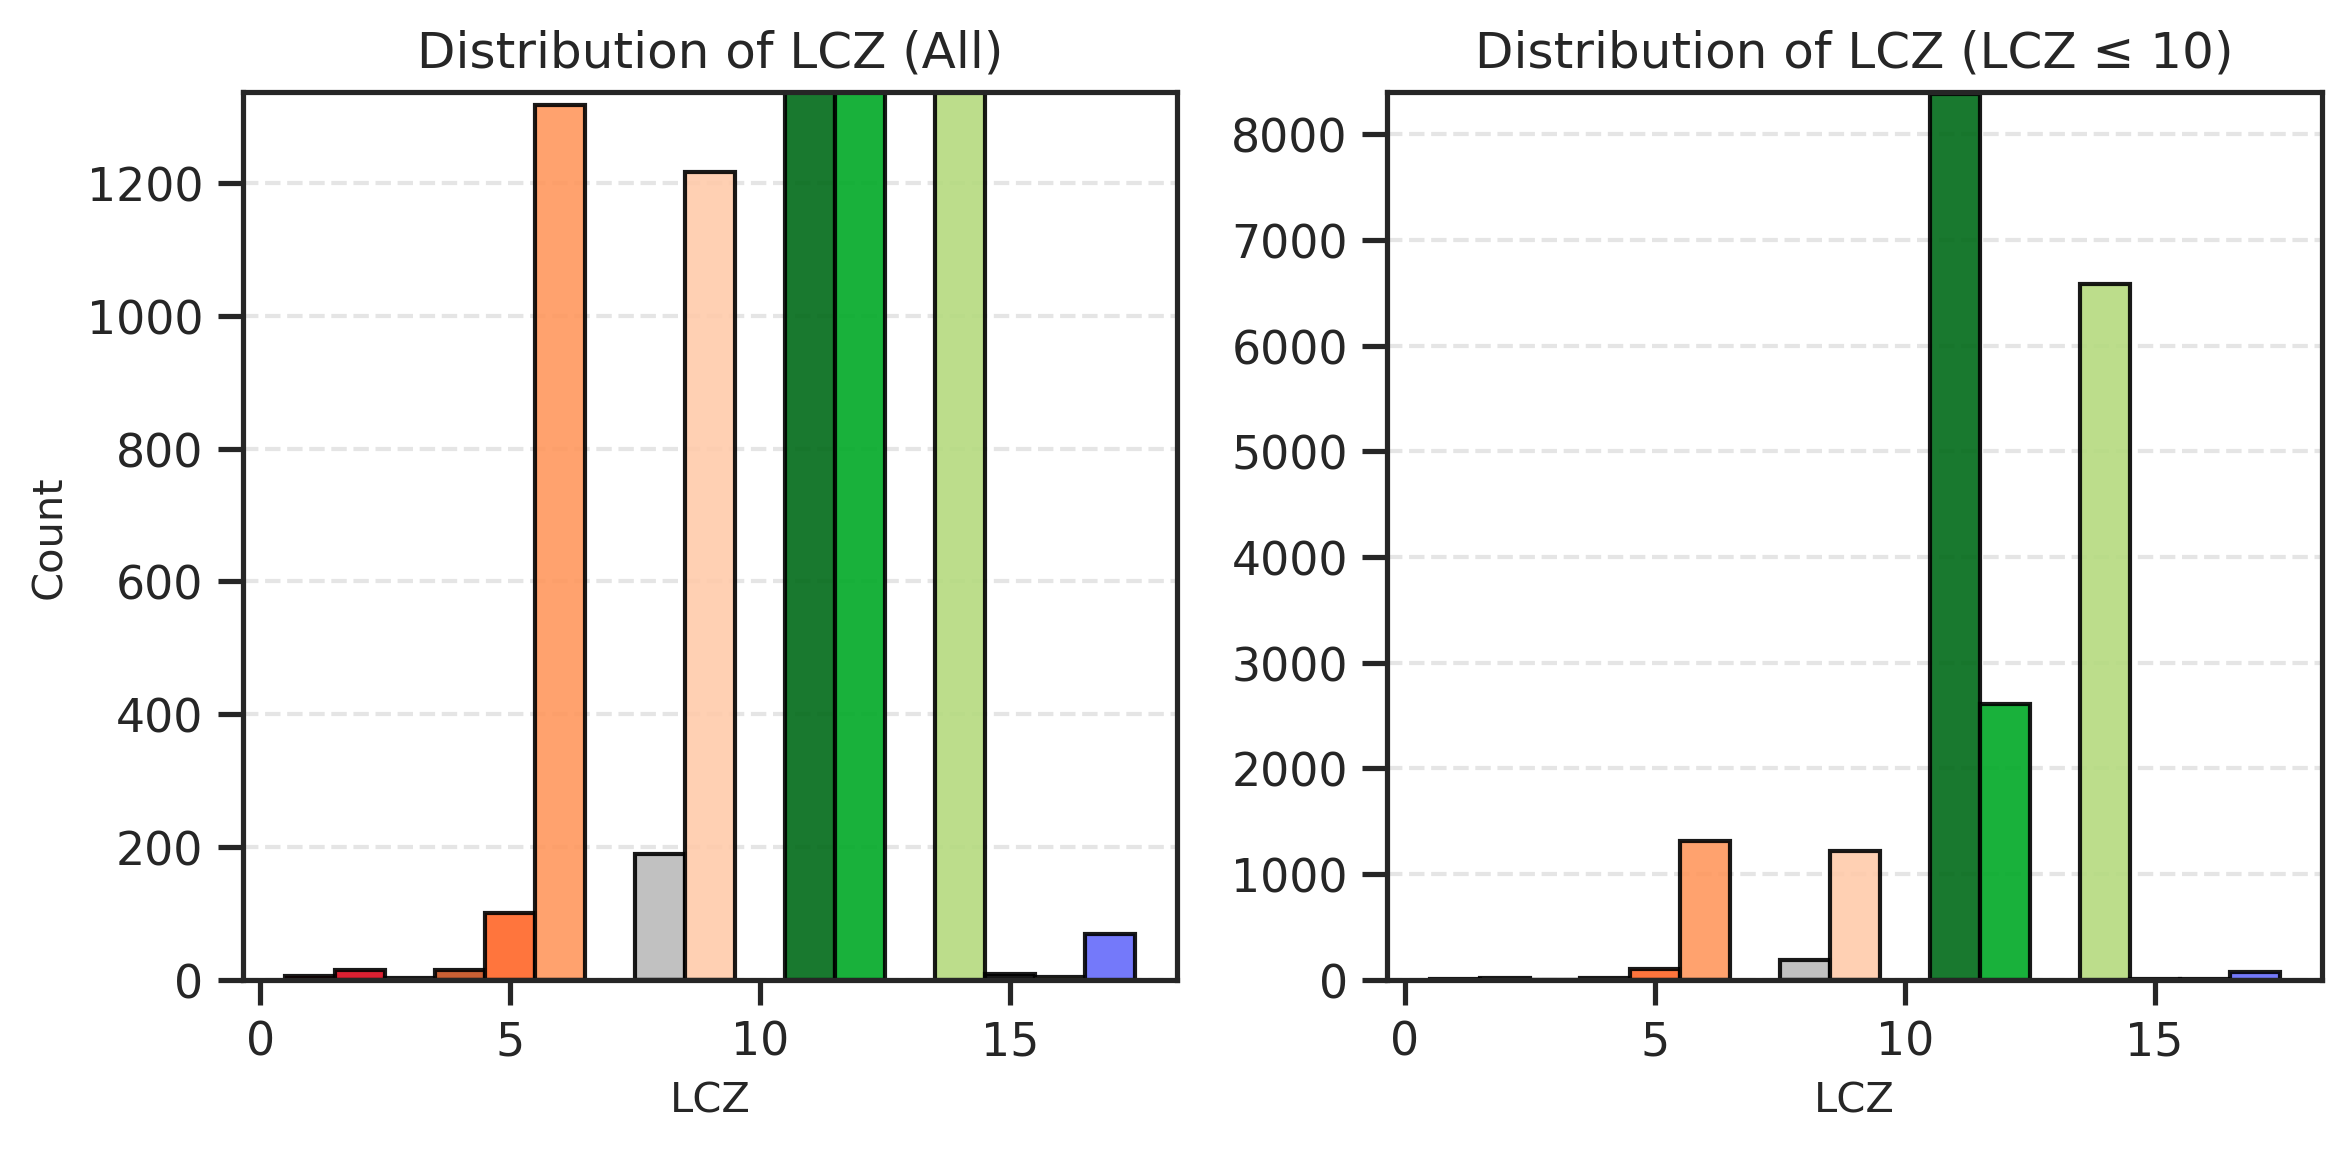

In [7]:
# Assuming df_combined and LCZ_hex are defined
source1 = df_combined[df_combined['LCZ'] <= 10]   # All data
source2 = df_combined[df_combined['LCZ'] > 10]  # Filtered data

# Calculate counts for each LCZ
counts1 = source1['LCZ'].value_counts(sort=False).sort_index()
counts2 = source2['LCZ'].value_counts(sort=False).sort_index()

counts1_normalized = counts1 / counts1.sum() * 100
counts2_normalized = counts2 / counts2.sum() * 100


# Get unique LCZ labels and sort
LCZ_labels = sorted(df_combined['LCZ'].unique())

# Filter colors to match the available LCZ labels
lcz_colors = [LCZ_hex[domain.index(lcz)] if lcz in domain else 'gray' for lcz in LCZ_labels]

# Calculate counts for each LCZ (ensure alignment with labels)
counts1 = source1['LCZ'].value_counts(sort=False).reindex(LCZ_labels, fill_value=0)
counts2 = source2['LCZ'].value_counts(sort=False).reindex(LCZ_labels, fill_value=0)

# Check alignment
#print(f"LCZ_labels: {LCZ_labels}")
#print(f"Colors: {lcz_colors}")
#print(f"Counts1: {counts1}")
#print(f"Counts2: {counts2}")

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300) # , sharey=True

# Calculate y-axis limits based on the data
ylim1 = counts1.max() + 20  # Add some padding
ylim2 = counts2.max() + 20

# First bar chart (all LCZ)
axes[0].bar(
    LCZ_labels, counts1.values, color=lcz_colors, edgecolor='black', alpha=0.9, width=1 
)
axes[1].bar(
    LCZ_labels, counts1.values, color=lcz_colors, edgecolor='black', alpha=0.9, width=1 
)
axes[0].set_title("Distribution of LCZ (All)", fontsize=12)
axes[0].set_xlabel("LCZ", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
#axes[0].tick_params(axis='both', labelsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_ylim(0, ylim1)  # Set unique y-axis limit

# Second bar chart (filtered LCZ ≤ 10)
axes[1].bar(
    LCZ_labels, counts2.values, color=lcz_colors, edgecolor='black', alpha=0.9, width=1 
)
axes[0].bar(
    LCZ_labels, counts2.values, color=lcz_colors, edgecolor='black', alpha=0.9, width=1 
)
axes[1].set_title("Distribution of LCZ (LCZ ≤ 10)", fontsize=12)
axes[1].set_xlabel("LCZ", fontsize=10)
#axes[1].tick_params(axis='both', labelsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, ylim2)  # Set unique y-axis limit

# Adjust layout and save
plt.tight_layout()
#fig.savefig("figures/LCZ_Distribution.svg", format='svg', bbox_inches='tight')

plt.show()


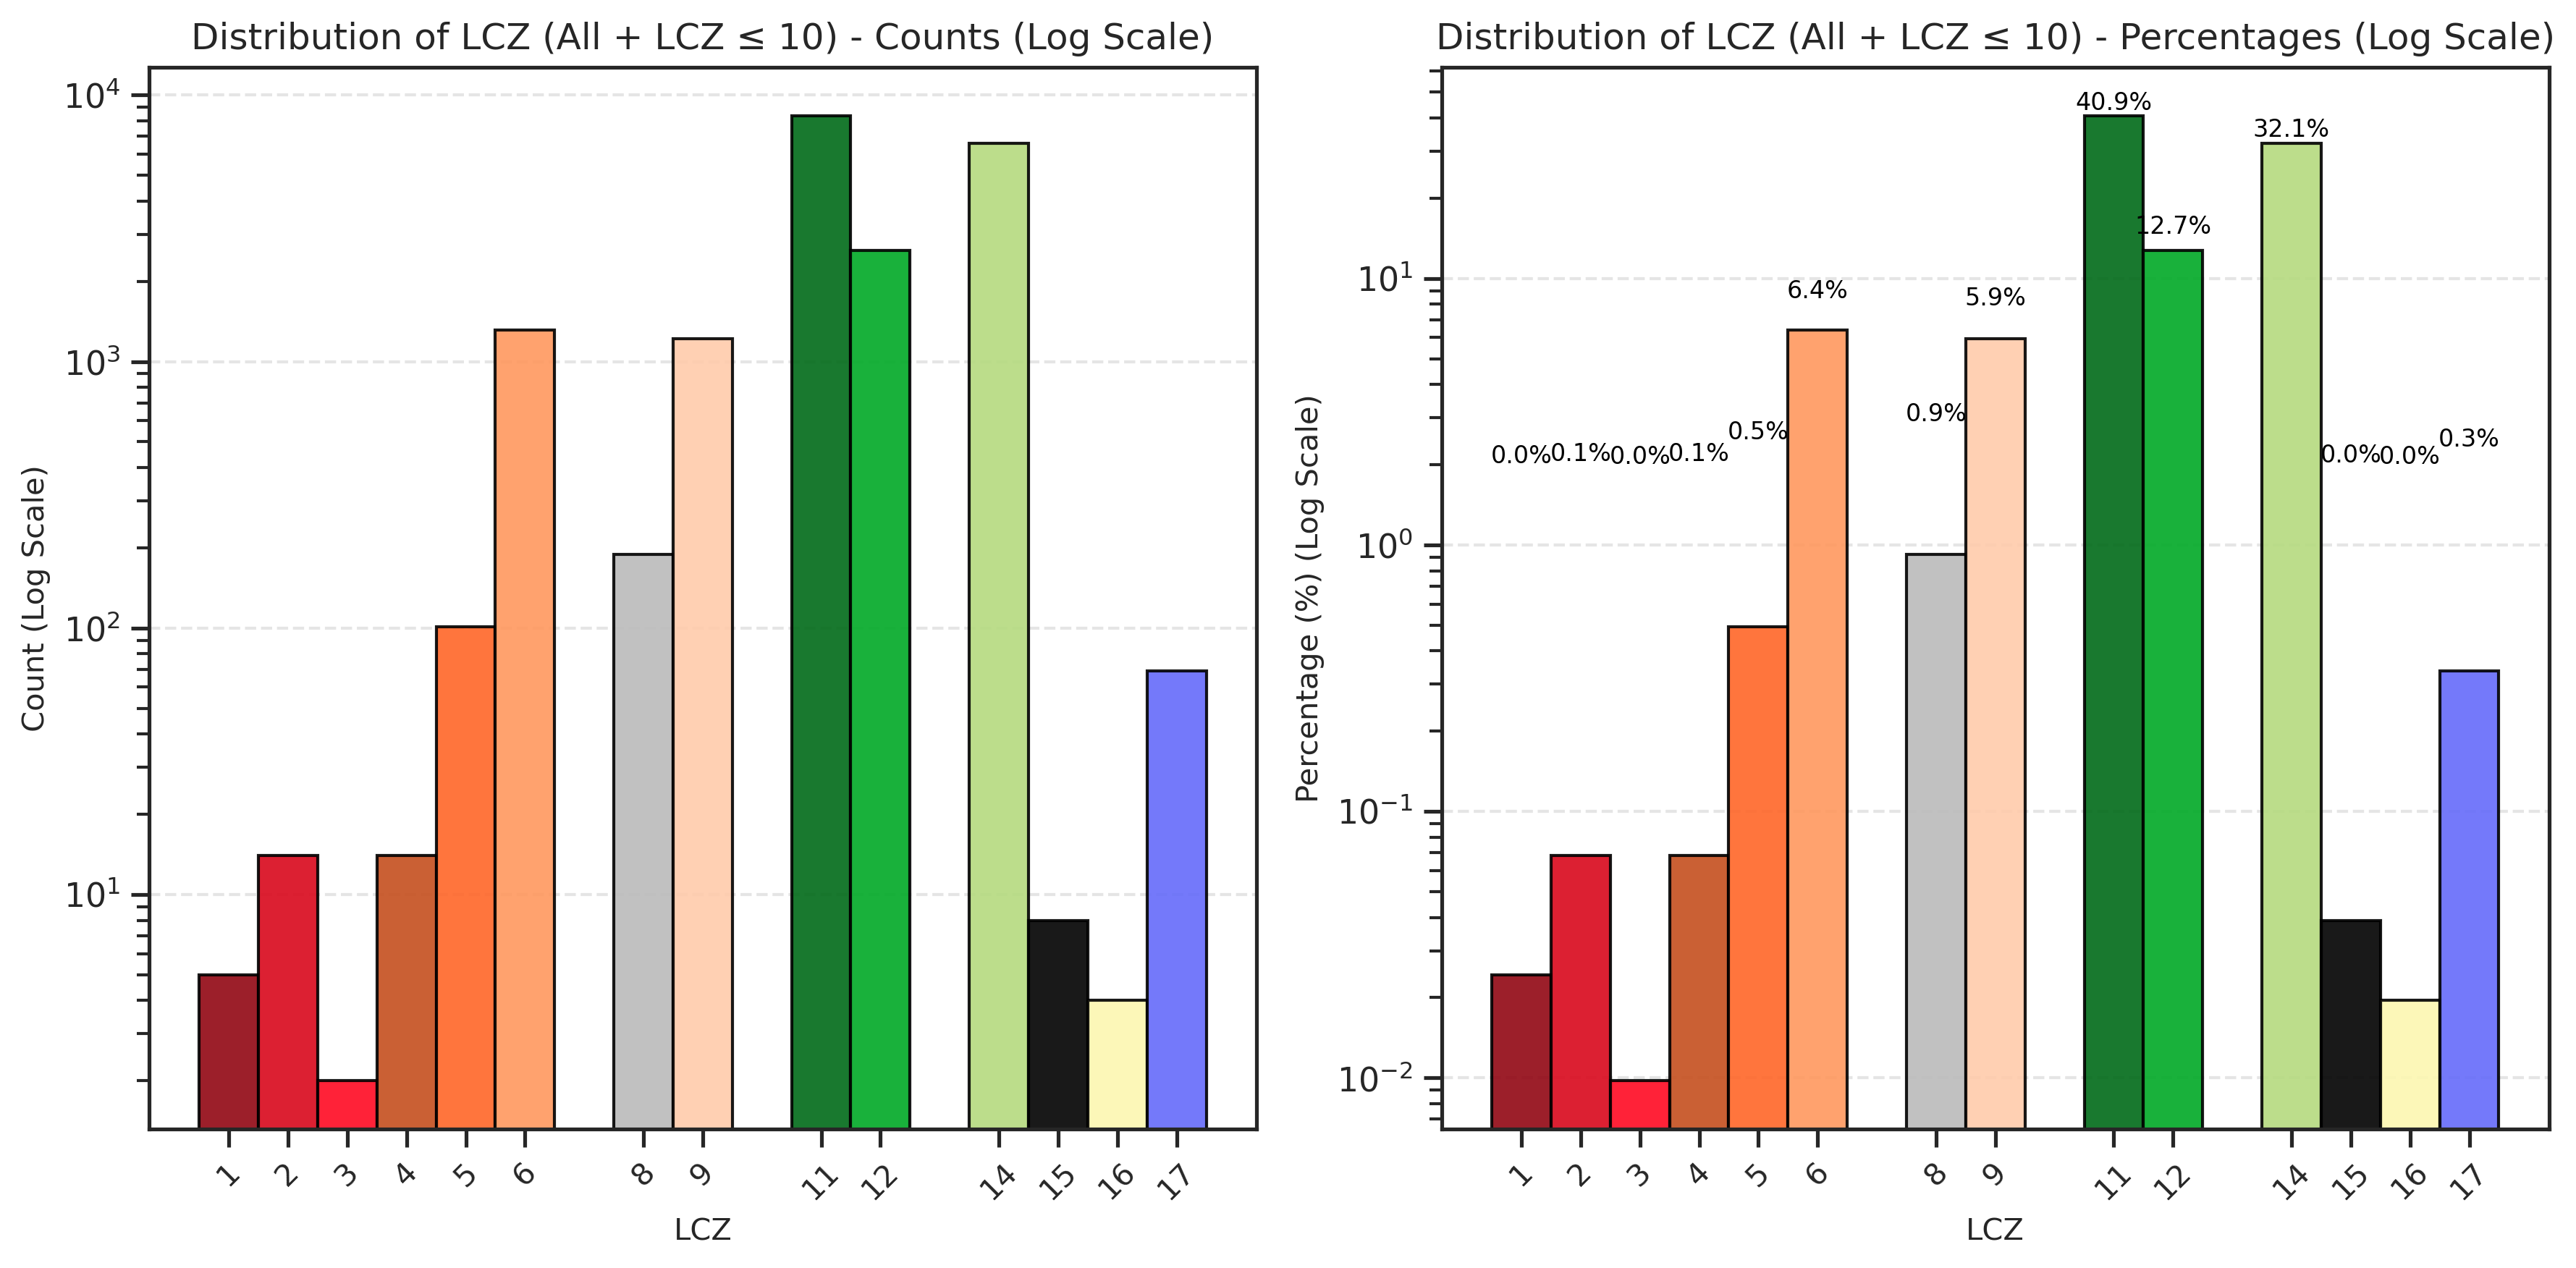

In [9]:
# Create the figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# Combine counts for all LCZ categories
LCZ_labels = sorted(df_combined['LCZ'].unique())
combined_counts = counts1.add(counts2, fill_value=0).reindex(LCZ_labels, fill_value=0)

# Normalize to percentages
combined_counts_normalized = combined_counts / combined_counts.sum() * 100

combined_colors = [
    LCZ_hex[domain.index(lcz)] if lcz in domain else 'gray' 
    for lcz in LCZ_labels
]


# Plot 1: Bar chart for counts (log scale)
axes[0].bar(
    LCZ_labels, combined_counts.values, color=combined_colors, edgecolor='black', alpha=0.9, width=1
)
axes[0].set_title("Distribution of LCZ (All + LCZ ≤ 10) - Counts (Log Scale)", fontsize=12)
axes[0].set_xlabel("LCZ", fontsize=10)
axes[0].set_ylabel("Count (Log Scale)", fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].set_yscale('log')  # Apply logarithmic scale to y-axis

# Set ticks on the x-axis for every LCZ value
axes[0].set_xticks(LCZ_labels)  # Set x-ticks to be LCZ labels
axes[0].set_xticklabels(LCZ_labels, fontsize=10, rotation=45)  # Adjust the size and rotation of the x-tick labels

# Plot 2: Bar chart for percentages (log scale)
axes[1].bar(
    LCZ_labels, combined_counts_normalized.values, color=combined_colors, edgecolor='black', alpha=0.9, width=1
)
axes[1].set_title("Distribution of LCZ (All + LCZ ≤ 10) - Percentages (Log Scale)", fontsize=12)
axes[1].set_xlabel("LCZ", fontsize=10)
axes[1].set_ylabel("Percentage (%) (Log Scale)", fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].set_yscale('log')  # Apply logarithmic scale to y-axis

# Set ticks on the x-axis for every LCZ value
axes[1].set_xticks(LCZ_labels)  # Set x-ticks to be LCZ labels
axes[1].set_xticklabels(LCZ_labels, fontsize=10, rotation=45)  # Adjust the size and rotation of the x-tick labels

# Add percentages on the percentage plot (second plot)
for i, bar in enumerate(axes[1].patches):  # Loop over bars in the second plot
    height = bar.get_height()
    ax_text = f"{height:.1f}%"  # Text to display the percentage
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, height + 2,  # Position text above the bar
        ax_text, ha='center', fontsize=8, color='black'  # Black text above the bar
    )

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure
fig.savefig("figures/LCZ_Distribution_Combined_Counts_Percentages_LogScale.svg", format='svg', bbox_inches='tight')
#fig.savefig("figures/LCZ_Distribution_Combined_Counts_Percentages_LogScale.png", format='png', bbox_inches='tight')

# Show the plots
plt.show()


## Plot: Scatterplot

In [15]:
df = df_combined
# Define the conditions for each category
condition1 = (df['Ta_13'] >= 0) & (df['Ta_01'] >= 0) # + +
condition2 = (df['Ta_13'] < 0) & (df['Ta_01'] < 0)   # - -
condition3 = (df['Ta_13'] < 0) & (df['Ta_01'] >= 0)  # - +
condition4 = (df['Ta_13'] >= 0) & (df['Ta_01'] < 0)  # + -

# Calculate the total number of people for each category
total_positive_positive = df[condition1]['people'].sum()
total_negative_negative = df[condition2]['people'].sum()
total_negative_positive = df[condition3]['people'].sum()
total_positive_negative = df[condition4]['people'].sum()

# Calculate the total number of people
total_people = df['people'].sum()

# Calculate the percentages
percent_positive_positive = round(total_positive_positive / total_people * 100,1)
percent_negative_negative = round(total_negative_negative / total_people * 100,1)
percent_negative_positive = round(total_negative_positive / total_people * 100,1)
percent_positive_negative = round(total_positive_negative / total_people * 100,1)

# Print the results
print("\nTotal people for each category:")
print(f"1. Ta_13 and Ta_01 positive: {total_positive_positive} and  {percent_positive_positive}")
print(f"2. Ta_13 and Ta_01 negative: {total_negative_negative} and  {percent_negative_negative}")
print(f"3. Ta_13 negative and Ta_01 positive: {total_negative_positive} and  {percent_negative_positive}")
print(f"4. Ta_13 positive and Ta_01 negative: {total_positive_negative} and  {percent_positive_negative}")

# Create a text annotation for the percentages
annotations_Ta = pd.DataFrame({
    'percent': [str(percent_positive_positive)+" %", str(percent_negative_negative)+" %", str(percent_negative_positive)+" %", str(percent_positive_negative)+" %"],
    'x': [2, -1.5, 2, -1.5],
    'y': [1.5, -2, -2, 1.5]
})


text_Ta = alt.Chart(annotations_Ta).mark_text(dx=0, dy=-2, color='black').encode(
    x='x',
    y='y',
    text=alt.Text('percent')
)

# --------------------------------------------------------------------------------

# Define the conditions for each category
condition1 = (df['LST_13'] >= 0) & (df['LST_01'] >= 0) # + +
condition2 = (df['LST_13'] < 0) & (df['LST_01'] < 0)   # - -
condition3 = (df['LST_13'] < 0) & (df['LST_01'] >= 0)  # - +
condition4 = (df['LST_13'] >= 0) & (df['LST_01'] < 0)  # + -

# Calculate the total number of people for each category
total_positive_positive = df[condition1]['people'].sum()
total_negative_negative = df[condition2]['people'].sum()
total_negative_positive = df[condition3]['people'].sum()
total_positive_negative = df[condition4]['people'].sum()

# Calculate the total number of people
total_people = df['people'].sum()

# Calculate the percentages
percent_positive_positive = round(total_positive_positive / total_people * 100,1)
percent_negative_negative = round(total_negative_negative / total_people * 100,1)
percent_negative_positive = round(total_negative_positive / total_people * 100,1)
percent_positive_negative = round(total_positive_negative / total_people * 100,1)

# Print the results
print("\nTotal people for each category:")
print(f"1. Ta_13 and Ta_01 positive: {total_positive_positive} and  {percent_positive_positive}")
print(f"2. Ta_13 and Ta_01 negative: {total_negative_negative} and  {percent_negative_negative}")
print(f"3. Ta_13 negative and Ta_01 positive: {total_negative_positive} and  {percent_negative_positive}")
print(f"4. Ta_13 positive and Ta_01 negative: {total_positive_negative} and  {percent_positive_negative}")

# Create a text annotation for the percentages
annotations_LST= pd.DataFrame({
    'percent': [str(percent_positive_positive)+" %", str(percent_negative_negative)+" %", str(percent_negative_positive)+" %", str(percent_positive_negative)+" %"],
    'x': [3, -2.5, 3, -2.5],
    'y': [6, -6, -6, 6]
})


text_LST = alt.Chart(annotations_LST).mark_text(dx=0, dy=-2, color='black').encode(
    x='x',
    y='y',
    text=alt.Text('percent')
)

# --------------------------------------------------------------------------------

# Define the conditions for each category
condition1 = (df['HUMIDEX_13_DT'] >= 0) & (df['HUMIDEX_01_DT'] >= 0) # + +
condition2 = (df['HUMIDEX_13_DT'] < 0) & (df['HUMIDEX_01_DT'] < 0)   # - -
condition3 = (df['HUMIDEX_13_DT'] < 0) & (df['HUMIDEX_01_DT'] >= 0)  # - +
condition4 = (df['HUMIDEX_13_DT'] >= 0) & (df['HUMIDEX_01_DT'] < 0)  # + -

# Calculate the total number of people for each category
total_positive_positive = df[condition1]['people'].sum()
total_negative_negative = df[condition2]['people'].sum()
total_negative_positive = df[condition3]['people'].sum()
total_positive_negative = df[condition4]['people'].sum()

# Calculate the total number of people
total_people = df['people'].sum()

# Calculate the percentages
percent_positive_positive = round(total_positive_positive / total_people * 100,1)
percent_negative_negative = round(total_negative_negative / total_people * 100,1)
percent_negative_positive = round(total_negative_positive / total_people * 100,1)
percent_positive_negative = round(total_positive_negative / total_people * 100,1)

# Print the results
print("\nTotal people for each category:")
print(f"1. Ta_13 and Ta_01 positive: {total_positive_positive} and  {percent_positive_positive}")
print(f"2. Ta_13 and Ta_01 negative: {total_negative_negative} and  {percent_negative_negative}")
print(f"3. Ta_13 negative and Ta_01 positive: {total_negative_positive} and  {percent_negative_positive}")
print(f"4. Ta_13 positive and Ta_01 negative: {total_positive_negative} and  {percent_positive_negative}")

# Create a text annotation for the percentages
annotations_HUMIDEX = pd.DataFrame({
    'percent': [str(percent_positive_positive)+" %", str(percent_negative_negative)+" %", str(percent_negative_positive)+" %", str(percent_positive_negative)+" %"],
    'x': [3.5, -1, 3.5, -1],
    'y': [1.5, -2.5, -2.5, 1.5]
})

text_HUMIDEX = alt.Chart(annotations_HUMIDEX).mark_text(dx=0, dy=-2, color='black').encode(
    x='x',
    y='y',
    text=alt.Text('percent')
)

# --------------------------------------------------------------------------------
source = df# df[df_combined['LCZ'] <= 10]

source["line"]=0
source["line_PET"]=23
source["line_HUMIDEX"]=30


# Zeile 1 Ta
m11 = alt.Chart(source, title="Land Surface Temperature Anomaly").mark_circle(size=25).encode(
    alt.Y('LST_13').scale(domain=[-8, 8]).title('ΔT at 13:00 hrs (°C)'),
    alt.X('LST_01').scale(domain=[-4, 4]).title('ΔT at 01:00 hrs (°C)'),
    color=alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex),
    size='people',
)+ text_LST

m12 = alt.Chart(source, title="Air Temperature Anomaly").mark_circle(size=25).encode(
    alt.Y('Ta_13').scale(domain=[-3, 3]).title('ΔT at 13:00 hrs (°C)'),
    alt.X('Ta_01').scale(domain=[-4, 4]).title('ΔT at 01:00 hrs (°C)'),
    color=alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex),
    size='people'
)+ text_Ta
m13 = alt.Chart(source, title="HUMIDEX Anomaly").mark_circle(size=25).encode(
    alt.Y('HUMIDEX_13_DT').scale(domain=[-3, 3]).title('ΔT at 13:00 hrs (°C)'),
    alt.X('HUMIDEX_01_DT').scale(domain=[-4, 4]).title('ΔT at 01:00 hrs (°C)'),
    color=alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex),
    size='people'
)+ text_HUMIDEX
m14 = alt.Chart(source,title="Physiological Equivalent Temperature").mark_circle(size=25, opacity=0.4).encode(
    alt.Y('PET_13').scale(zero=False).title('T at 13:00 hrs (°C)'),
    alt.X('LCZ:N').scale(zero=False).title('Local Climate Zone'),
    color=alt.Color('LCZ:N').scale(domain=domain, range=LCZ_hex),
    size='people'
)

vertline = alt.Chart(source).mark_rule().encode(
    x='line:Q'
)


yline = alt.Chart(source).mark_rule().encode(
    y='line:Q'
)


vertline_PET = alt.Chart(source).mark_rule().encode(
    x='line_PET:Q'
)

yline_PET = alt.Chart(source).mark_rule().encode(
    y='line_PET:Q'
)


vertline_HUMIDEX = alt.Chart(source).mark_rule().encode(
    x='line_HUMIDEX:Q'
)

yline_HUMIDEX = alt.Chart(source).mark_rule().encode(
    y='line_HUMIDEX:Q'
)



chart = (m11+vertline+yline| m12+vertline+yline| m13+vertline+yline|m14) #+yline_PET)
# chart


Total people for each category:
1. Ta_13 and Ta_01 positive: 1883123 and  31.8
2. Ta_13 and Ta_01 negative: 1747906 and  29.5
3. Ta_13 negative and Ta_01 positive: 1277880 and  21.6
4. Ta_13 positive and Ta_01 negative: 1020191 and  17.2

Total people for each category:
1. Ta_13 and Ta_01 positive: 2057005 and  34.7
2. Ta_13 and Ta_01 negative: 1675448 and  28.3
3. Ta_13 negative and Ta_01 positive: 1218425 and  20.5
4. Ta_13 positive and Ta_01 negative: 978222 and  16.5

Total people for each category:
1. Ta_13 and Ta_01 positive: 1515340 and  25.6
2. Ta_13 and Ta_01 negative: 1806252 and  30.5
3. Ta_13 negative and Ta_01 positive: 1550137 and  26.1
4. Ta_13 positive and Ta_01 negative: 1056091 and  17.8


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


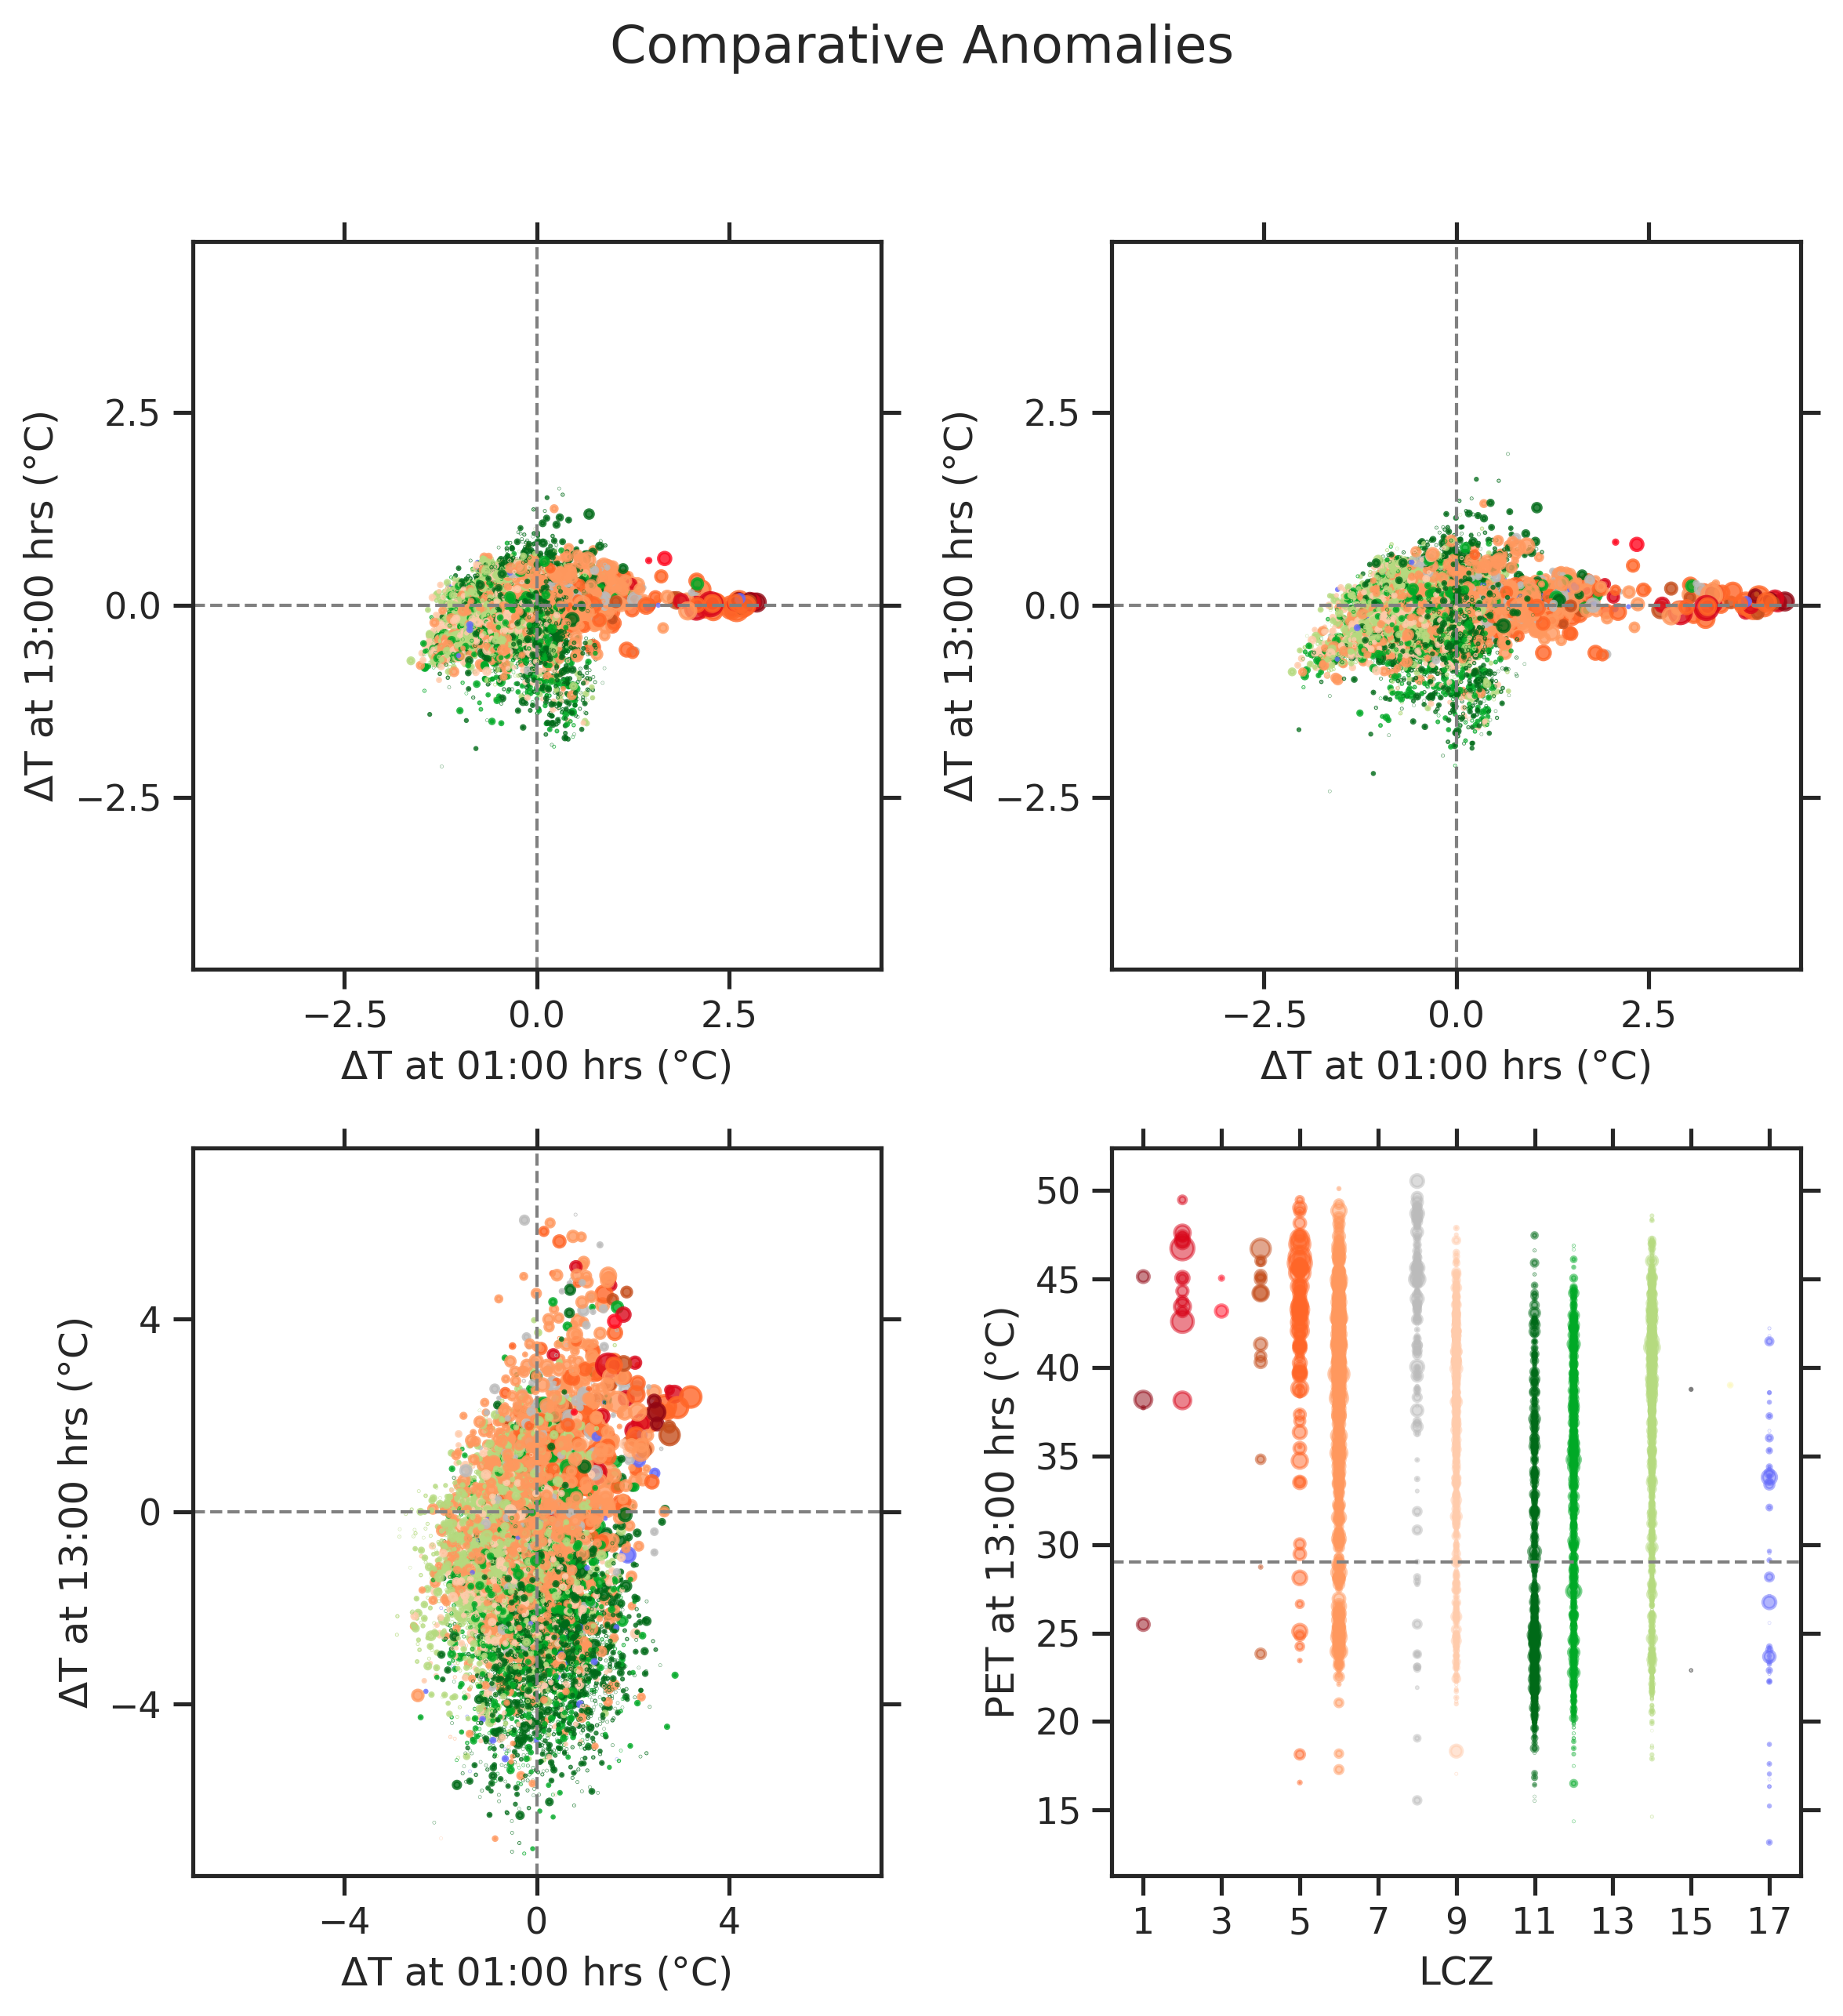

In [ ]:
lcz_cmap = ListedColormap(LCZ_hex)

# Define LCZ color legend
lcz_patches = [
    mpatches.Patch(color=lcz_cmap(i), label=f"LCZ {domain[i]}")
    for i in range(len(domain))
]

# Define rounded population values for the size legend
rounded_sizes = [1000, 5000, 10000, 50000]  # Example rounded values
max_population = df['people'].max()
size_legend = [
    mlines.Line2D(
        [], [], color='gray', marker='o', linestyle='None',
        markersize=np.sqrt(size / max_population * 50),  # Scale the sizes
        label=f"{size:,} people"  # Format numbers with commas
    )
    for size in rounded_sizes
]

# Prepare data for plotting
x_LST = df['LST_01']
y_LST = df['LST_13']
x_Ta = df['Ta_01']
y_Ta = df['Ta_13']
x_HUMIDEX = df['HUMIDEX_01_DT']
y_HUMIDEX = df['HUMIDEX_13_DT']
x_PET = df['PET_13']
y_PET = df['LCZ']
people = df['people']



# Create a color array based on LCZ values
color_indices = [domain.index(lcz) for lcz in df['LCZ']]
colors = lcz_cmap(color_indices)

# Scale the circle size based on 'people'
scaled_sizes = df['people'] / df['people'].max() * 50  # Scale to a reasonable size

# Define annotations for percentages
annotations_LST = [
    (3, 6.6, f"{percent_positive_positive}%"),
    (-3, -6.6, f"{percent_negative_negative}%"),
    (3, -6.6, f"{percent_negative_positive}%"),
    (-3, 6.6, f"{percent_positive_negative}%")
]

annotations_Ta = [
    (3, 4, f"{percent_positive_positive}%"),
    (-3, -4, f"{percent_negative_negative}%"),
    (3, -4, f"{percent_negative_positive}%"),
    (-3, 4, f"{percent_positive_negative}%")
]

annotations_HUMIDEX = [
    (3, 4, f"{percent_positive_positive}%"),
    (-3, -4, f"{percent_negative_negative}%"),
    (3, -4, f"{percent_negative_positive}%"),
    (-3, 4, f"{percent_positive_negative}%")
]

# Common function for scatter plot
def plot_chart(ax, x, y, title, x_label, y_label, annotations, xlim,ylim):
    scatter = ax.scatter(x, y, s=scaled_sizes, c=colors, alpha=0.8, edgecolors=None, label='People')
    ax.axhline(0, color='grey', linewidth=1, linestyle='--')
    ax.axvline(0, color='grey', linewidth=1, linestyle='--')
    # ax.set_title(title, fontsize=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xlim([-xlim, xlim])  # Apply x-axis limits
    ax.set_ylim([-ylim, ylim])  # Apply y-axis limits

    # Set same number of ticks for x and y axes
    ticks = np.linspace(-xlim, xlim, num=5)  # Adjust num for number of ticks
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # Maintain equal aspect ratio
    ax.set_aspect('equal', adjustable='datalim')


    # Add ticks to top and right
    ax.tick_params(axis='both', which='both', direction='out', top=True, right=True)
   
    # ax.grid(False)
    
#    for ann_x, ann_y, ann_text in annotations:
#        ax.text(ann_x, ann_y, ann_text, fontsize=10, color='black', ha='center')


# Create the figure
fig, axes = plt.subplots(2, 2, figsize=(8, 9), dpi=300)
fig.suptitle("Comparative Anomalies", fontsize=16)

# LST Plot
plot_chart(
    axes[1, 0], x_LST, y_LST, "Land Surface Temperature Anomaly",
    "ΔT at 01:00 hrs (°C)", "ΔT at 13:00 hrs (°C)", annotations_LST, xlim=8, ylim=8
)

# Ta Plot
plot_chart(
    axes[0,0], x_Ta, y_Ta, "Air Temperature Anomaly",
    "ΔT at 01:00 hrs (°C)", "ΔT at 13:00 hrs (°C)", annotations_Ta, xlim=5, ylim=5
)

# HUMIDEX Plot
plot_chart(
    axes[0,1], x_HUMIDEX, y_HUMIDEX, "HUMIDEX Anomaly",
    "ΔT at 01:00 hrs (°C)", "ΔT at 13:00 hrs (°C)", annotations_HUMIDEX, xlim=5, ylim=5
)

# PET Plot
scatter_PET = axes[1, 1].scatter(
    df["LCZ"],x_PET,
    s=scaled_sizes,  # Scale size by "people"
    c=colors,
    alpha=0.5,
    #edgecolors='k'
)
# Add 28-degree line
axes[1, 1].axhline(29, color='grey', linewidth=1, linestyle='--', label='29°C')
# axes[1, 1].set_title("Physiological Equivalent Temperature (PET)", fontsize=14)
axes[1, 1].set_ylabel("PET at 13:00 hrs (°C)", fontsize=12)
axes[1, 1].set_xticks(np.arange(df["LCZ"].min(), df["LCZ"].max() + 1, 2))
axes[1, 1].set_xlabel("LCZ", fontsize=12)
#axes[1, 1].legend()  # Add a legend to identify the 28°C line
    # Add ticks to top and right
axes[1, 1].tick_params(axis='both', which='both', direction='out', top=True, right=True)

# Add legends
#lc = fig.legend(handles=lcz_patches, loc='lower center', bbox_to_anchor=(0.5, -0.25),
#                       title="LCZ Colors", fontsize=10, title_fontsize=10, ncol=5)
#sz = fig.legend(handles=size_legend, loc='lower center', bbox_to_anchor=(0.5, -0.1),
#                         title="Population Density", fontsize=10, title_fontsize=10)
 
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

#plt.show()

# Export the figure to an SVG file
fig.savefig("figures/figure_01_scatterplot.svg", format='svg', bbox_inches='tight')
fig.savefig("figures/figure_01_scatterplot.png", format='png', bbox_inches='tight')

## Temporal Variations

In [47]:
df_combined_24h_HUMIDEX_DT = pd.read_csv("../data/df_combined_output_24h_HUMIDEX_DT.csv",sep=";")
df_combined_24h_Heat_Index_DT = pd.read_csv("../data/df_combined_output_24h_Heat_Index_DT.csv",sep=";")
df_combined_24h_HOSTRADA_DT = pd.read_csv("../data/df_combined_output_24h_HOSTRADA_DT.csv",sep=";")
df_combined_24h_HOSTRADA_DT_90th = pd.read_csv("../data/df_combined_output_24h_HOSTRADA_DT_90th.csv",sep=";")

Summary statistics for Daytime Temperature Distribution for LCZ 1-3:
               count      mean       std       min       50%       90%  \
Dataset                                                                  
HOSTRADA       273.0  0.487944  0.537402 -0.529029  0.339280  1.283066   
HOSTRADA_90th  273.0  0.627875  0.699614 -0.600000  0.400000  1.800000   
HUMIDEX        221.0  0.335801  0.721789 -0.718146  0.074649  1.336259   

                    max  
Dataset                  
HOSTRADA       2.140555  
HOSTRADA_90th  2.700000  
HUMIDEX        3.099764  
Summary statistics for Nighttime Temperature Distribution for LCZ 1-3:
               count      mean       std       min       50%       90%  \
Dataset                                                                  
HOSTRADA       273.0  1.579293  0.808159 -0.314824  1.616773  2.629850   
HOSTRADA_90th  273.0  1.934432  0.963691 -0.200000  2.100000  3.174000   
HUMIDEX        221.0  1.442055  1.465970 -0.882032  1.140794  3

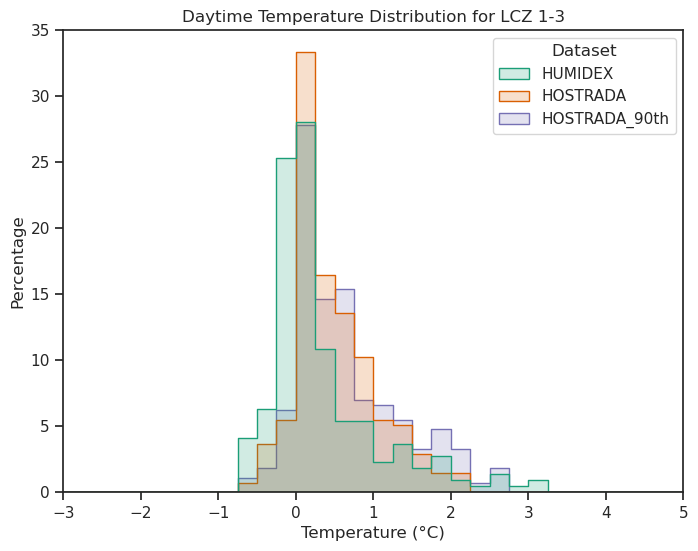

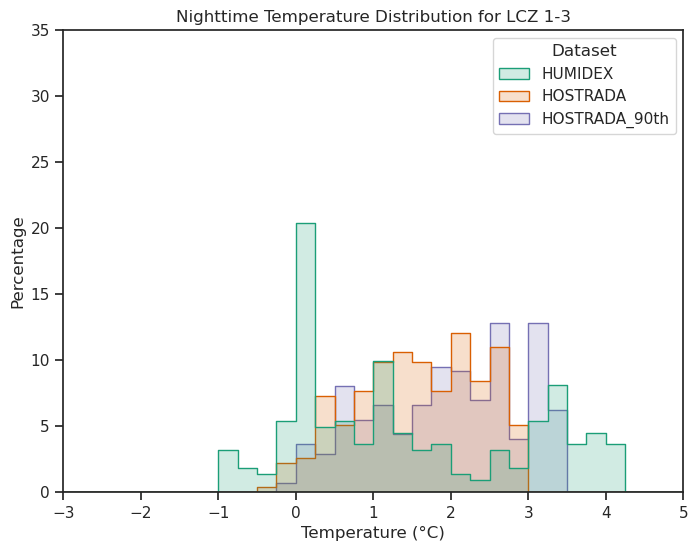

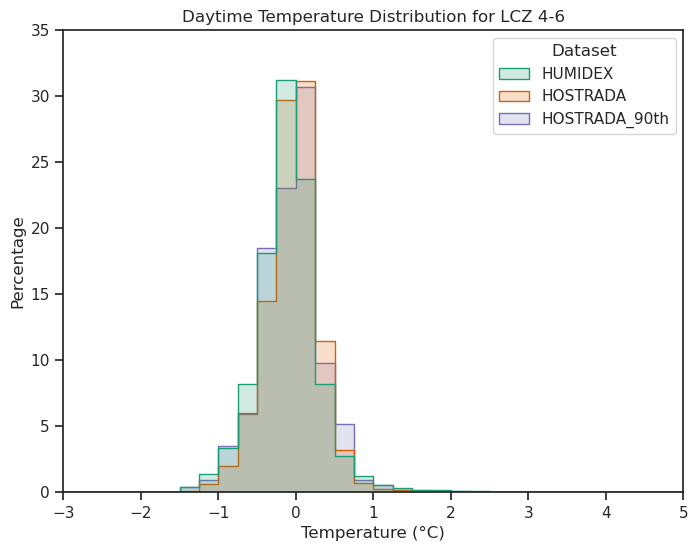

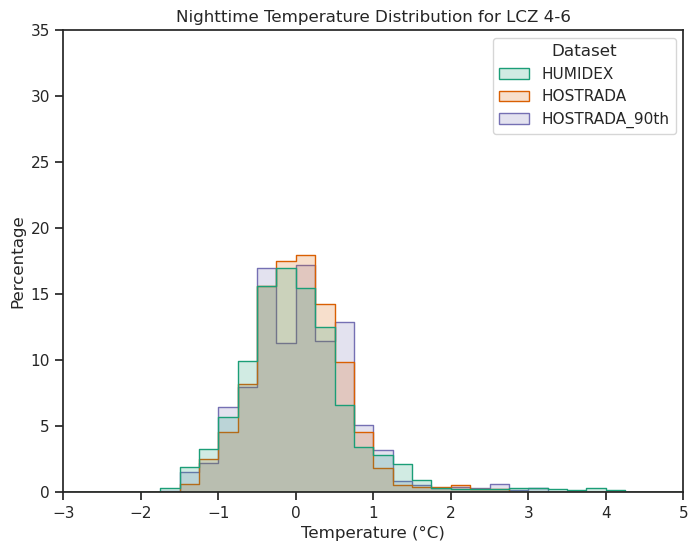

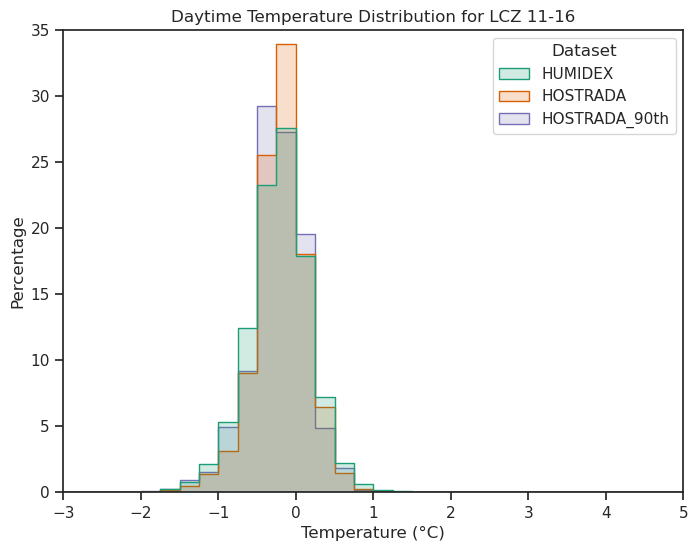

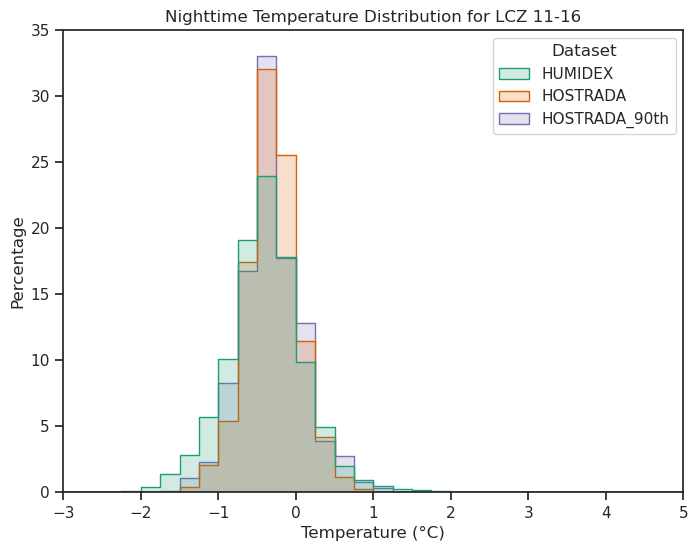

In [14]:

# Define the day and night time ranges
daytime_hours = ["06:00", "07:00", "08:00", "09:00", "10:00", "11:00", "12:00", "13:00", "14:00", "15:00", "16:00", "17:00", "18:00"]
nighttime_hours = ["18:00", "19:00", "20:00", "21:00", "22:00", "23:00", "00:00", "01:00", "02:00", "03:00", "04:00", "05:00", "06:00"]

# Extract temperature data for each dataset
temp1 = df_combined_24h_HUMIDEX_DT["Temperature"]
temp2 = df_combined_24h_HOSTRADA_DT["Temperature"]
temp3 = df_combined_24h_HOSTRADA_DT_90th["Temperature"]

# Determine the global min and max temperature values
min_temp = min(temp1.min(), temp2.min(), temp3.min())
max_temp = max(temp1.max(), temp2.max(), temp3.max())

# Define custom bin edges with a step size of 0.25 (from -0.5, 0.5, 1.5, ...)
bins = np.arange(np.floor(min_temp) - 0.5, np.ceil(max_temp) + 1.5, 0.25)

# Create a function to plot histograms for each LCZ group across all datasets
def plot_lcz_temperature_distributions(lcz_groups, title, time_filter):
    # Combine the data from all datasets into one dataframe, including 'LCZ' and 'Dataset' columns
    df_combined = pd.concat([
        df_combined_24h_HUMIDEX_DT[["Temperature", "LCZ", "Column"]].assign(Dataset='HUMIDEX'),
        df_combined_24h_HOSTRADA_DT[["Temperature", "LCZ", "Column"]].assign(Dataset='HOSTRADA'),
        df_combined_24h_HOSTRADA_DT_90th[["Temperature", "LCZ", "Column"]].assign(Dataset='HOSTRADA_90th')
    ])
    
    # Filter by LCZ groups and time (day or night)
    df_filtered = df_combined[
        df_combined["LCZ"].isin(lcz_groups) & df_combined["Column"].isin(time_filter)
    ]
    
    # Calculate and display summary statistics
    summary_stats = df_filtered.groupby("Dataset")["Temperature"].describe(percentiles=[.5, .9])
    print(f"Summary statistics for {title}:")
    print(summary_stats)

    # Define custom colors for each dataset
    palette = {
        'HUMIDEX': '#1b9e77',  # Green
        'HOSTRADA': '#d95f02',  # Orange
        'HOSTRADA_90th': '#7570b3'  # Purple
    }
    
    # Create a figure for plotting
    plt.figure(figsize=(8, 6))
    
    # Plot histograms for each LCZ group and dataset using sns.histplot
    sns.histplot(data=df_filtered, x="Temperature", hue="Dataset", bins=bins, element="step", stat="percent", common_norm=False, alpha=0.2, palette=palette)
    
    # Add labels and title
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Percentage")
    plt.title(title)
    
    # Set y-axis limits
    plt.ylim(0, 35)
    plt.xlim(-3, 5)
    
    # Save the plot
    plt.savefig("figures/figure_stats_" + title.replace(" ", "_") + ".svg", format='svg', bbox_inches='tight')

# Plot the distributions for each LCZ group and time period
plot_lcz_temperature_distributions([1, 2, 3], "Daytime Temperature Distribution for LCZ 1-3", daytime_hours)
plot_lcz_temperature_distributions([1, 2, 3], "Nighttime Temperature Distribution for LCZ 1-3", nighttime_hours)
plot_lcz_temperature_distributions([4, 5, 6], "Daytime Temperature Distribution for LCZ 4-6", daytime_hours)
plot_lcz_temperature_distributions([4, 5, 6], "Nighttime Temperature Distribution for LCZ 4-6", nighttime_hours)
plot_lcz_temperature_distributions([11, 12, 13, 14, 15, 16], "Daytime Temperature Distribution for LCZ 11-16", daytime_hours)
plot_lcz_temperature_distributions([11, 12, 13, 14, 15, 16], "Nighttime Temperature Distribution for LCZ 11-16", nighttime_hours)


Summary statistics for Temperature Distribution for LCZ 1-3 Across Datasets:
               count      mean       std       min       50%      90%  \
Dataset                                                                 
HOSTRADA       504.0  1.025019  0.894281 -0.529029  0.796374  2.44166   
HOSTRADA_90th  504.0  1.261766  1.085019 -0.600000  1.000000  3.00000   
HUMIDEX        408.0  0.880386  1.294326 -0.882032  0.264473  3.30953   

                    max  
Dataset                  
HOSTRADA       2.943216  
HOSTRADA_90th  3.430000  
HUMIDEX        4.167459  

HUMIDEX - Additional Statistics:
  90th Percentile: 3.31
  Median: 0.26
  Mean: 0.88
  Min: -0.88
  Max: 4.17

HOSTRADA - Additional Statistics:
  90th Percentile: 2.44
  Median: 0.80
  Mean: 1.03
  Min: -0.53
  Max: 2.94

HOSTRADA_90th - Additional Statistics:
  90th Percentile: 3.00
  Median: 1.00
  Mean: 1.26
  Min: -0.60
  Max: 3.43
Summary statistics for Temperature Distribution for LCZ 4-6 Across Datasets:
          

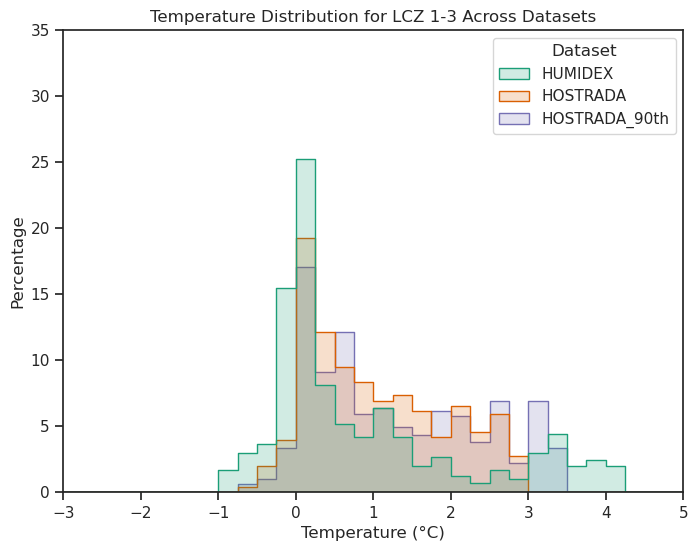

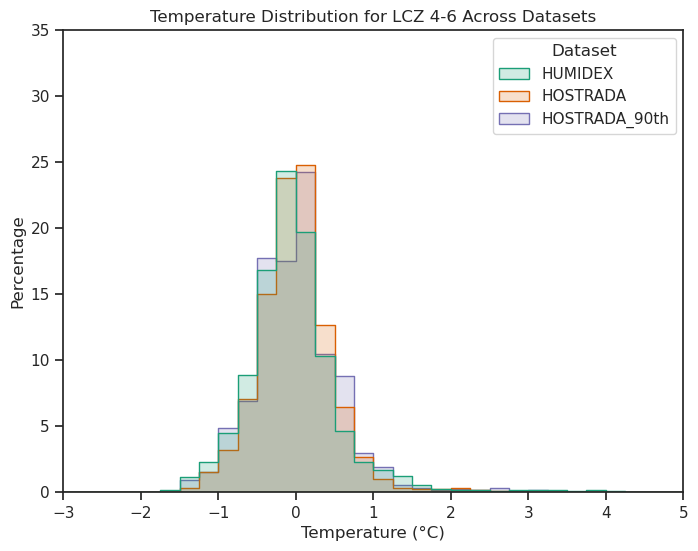

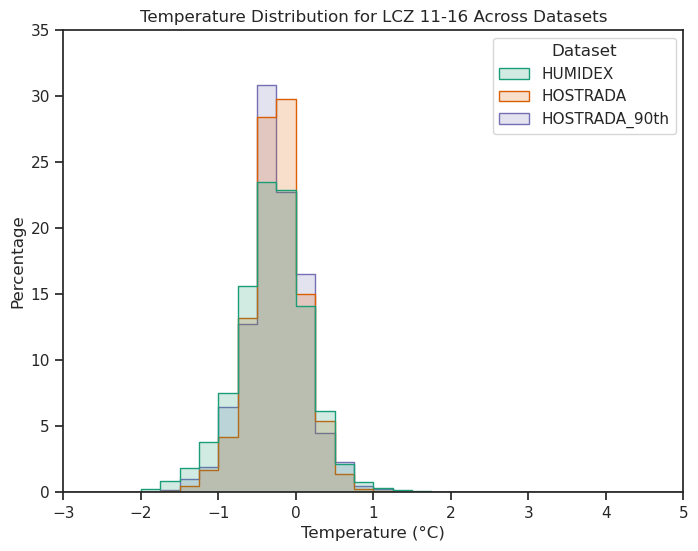

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract temperature data for each dataset
temp1 = df_combined_24h_HUMIDEX_DT["Temperature"]
temp2 = df_combined_24h_HOSTRADA_DT["Temperature"]
temp3 = df_combined_24h_HOSTRADA_DT_90th["Temperature"]

# Determine the global min and max temperature values
min_temp = min(temp1.min(), temp2.min(), temp3.min())
max_temp = max(temp1.max(), temp2.max(), temp3.max())

# Define custom bin edges with a step size of 0.25 (from -0.5, 0.5, 1.5, ...)
bins = np.arange(np.floor(min_temp) - 0.5, np.ceil(max_temp) + 1.5, 0.25)

# Create a function to plot histograms for each LCZ group across all datasets
def plot_lcz_temperature_distributions(lcz_groups, title):
    # Combine the data from all datasets into one dataframe, including 'LCZ' and 'Dataset' columns
    df_combined = pd.concat([
        df_combined_24h_HUMIDEX_DT[["Temperature", "LCZ"]].assign(Dataset='HUMIDEX'),
        df_combined_24h_HOSTRADA_DT[["Temperature", "LCZ"]].assign(Dataset='HOSTRADA'),
        df_combined_24h_HOSTRADA_DT_90th[["Temperature", "LCZ"]].assign(Dataset='HOSTRADA_90th')
    ])
    
    # Filter by LCZ groups
    df_filtered = df_combined[df_combined["LCZ"].isin(lcz_groups)]
    
    # Calculate and display summary statistics
    summary_stats = df_filtered.groupby("Dataset")["Temperature"].describe(percentiles=[.5, .9])
    print(f"Summary statistics for {title}:")
    print(summary_stats)

    # Calculate additional percentiles
    for dataset in df_filtered["Dataset"].unique():
        dataset_data = df_filtered[df_filtered["Dataset"] == dataset]["Temperature"]
        print(f"\n{dataset} - Additional Statistics:")
        print(f"  90th Percentile: {np.percentile(dataset_data, 90):.2f}")
        print(f"  Median: {np.median(dataset_data):.2f}")
        print(f"  Mean: {np.mean(dataset_data):.2f}")
        print(f"  Min: {dataset_data.min():.2f}")
        print(f"  Max: {dataset_data.max():.2f}")
    
    # Define custom colors for each dataset
    palette = {
        'HUMIDEX': '#1b9e77',  # Green
        'HOSTRADA': '#d95f02',  # Orange
        'HOSTRADA_90th': '#7570b3'  # Purple
    }
    
    # Create a figure for plotting
    plt.figure(figsize=(8, 6))
    
    # Plot histograms for each LCZ group and dataset using sns.histplot
    sns.histplot(data=df_filtered, x="Temperature", hue="Dataset", bins=bins, element="step", stat="percent", common_norm=False, alpha=0.2, palette=palette)
    
    # Add labels and title
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Percentage")
    plt.title(title)
    
    # Set y-axis limits from 0 to 1
    plt.ylim(0, 35)
    plt.xlim(-3,5)
    
    # Manually add the legend with custom labels
    #plt.legend()
    
    # Display the plot
    #plt.show()
    plt.savefig("figures/figure_stats_"+title+".svg", format='svg', bbox_inches='tight')

# Plot the distributions for each LCZ group
plot_lcz_temperature_distributions([1, 2, 3], "Temperature Distribution for LCZ 1-3 Across Datasets")
plot_lcz_temperature_distributions([4, 5, 6], "Temperature Distribution for LCZ 4-6 Across Datasets")
plot_lcz_temperature_distributions([11, 12, 13, 14, 15, 16], "Temperature Distribution for LCZ 11-16 Across Datasets")


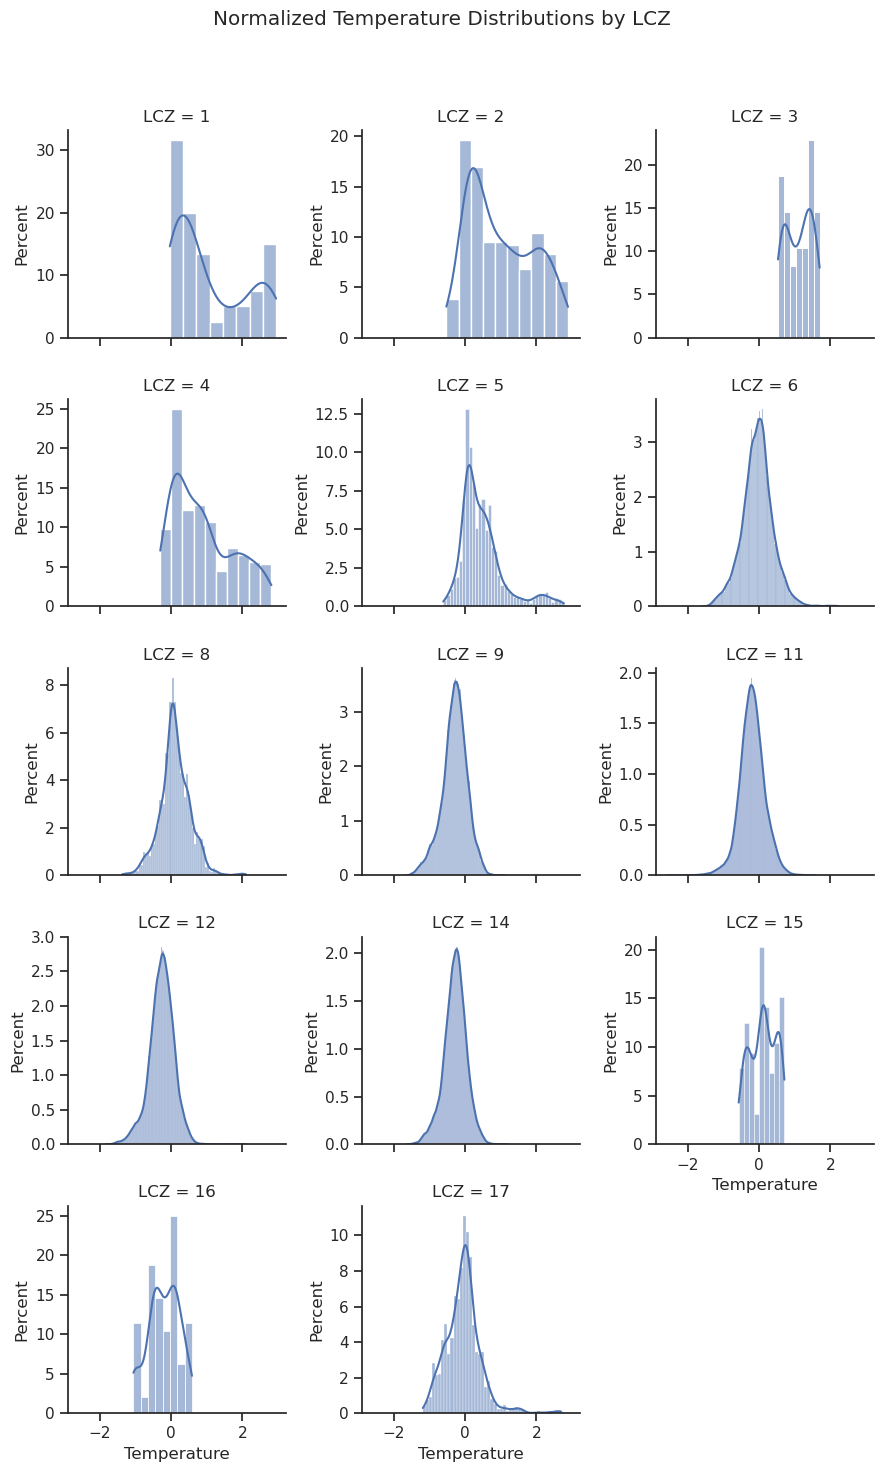

In [17]:
# Create a FacetGrid for LCZ categories with normalized histograms
g = sns.FacetGrid(df_combined_24h_HOSTRADA_DT, col="LCZ", col_wrap=3, sharey=False)

# Map the histogram plot with KDE and normalization
g.map(sns.histplot, "Temperature", kde=True, stat="percent")

# Adjust layout and add a title
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Normalized Temperature Distributions by LCZ")
plt.show()

In [16]:
def plot_24h_matplot(source, parameter):
    # Calculate mean and standard deviation per Column for each LCZ
    stats = source.groupby(['Column', 'LCZ'])['Temperature'].agg(['mean', 'std']).reset_index()

    # Convert 'Column' to datetime (hour format)
    stats['Column'] = pd.to_datetime(stats['Column'], format='%H:%M')

    # Extract unique LCZ values and their corresponding colors
    unique_lcz = stats['LCZ'].unique()
    colors = {lcz: LCZ_hex[domain.index(lcz)] for lcz in unique_lcz}  # Map LCZ to colors

    # Define marker sizes based on LCZ categories
    marker_sizes = {lcz: 14 if lcz in [1, 2, 3] else (12 if lcz in [4, 5, 6] else 10) for lcz in unique_lcz}


    # Prepare the figure with two subplots (one above the other)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True, dpi=100)
    
    # Plot mean temperature for each LCZ in the first subplot
    for lcz in reversed(unique_lcz):
        lcz_data = stats[stats['LCZ'] == lcz]
        ax1.plot(
            lcz_data['Column'],  # X-axis
            lcz_data['mean'],  # Y-axis (mean temperature)
            label=f"LCZ {lcz}",
            linestyle=(0, (5, 5)),  # Dashed line
            marker='o',  # Points on the line
            color=colors[lcz],
            markersize=marker_sizes[lcz],  # Dynamic marker size
            #markersize=12,  # Increase the size of the points
            markeredgewidth=0.5,  # Set the width of the marker edge (black border)
            markeredgecolor='black'  # Set the color of the marker border (black)
        )

    # Set specific x-axis ticks and labels for the first plot
    tick_positions = pd.to_datetime(['06:00', '12:00', '18:00'], format='%H:%M')
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels([time.strftime('%H:%M') for time in tick_positions], rotation=90, fontsize=10)

    # Add title and axis labels to the first plot
    ax1.set_ylabel("Mean Temperature (°C)", fontsize=12)
    ax1.grid(visible=True, linestyle='--', alpha=0.5)
    ax1.tick_params(axis='both', which='both', direction='out', top=True, right=True)
    ax1.set_ylim([-3.4, 3.4])
    ax1.set_xlim([pd.to_datetime(['00:00'], format='%H:%M'),pd.to_datetime(['23:00'], format='%H:%M')])
    

    # Plot standard deviation for urban areas in the second subplot
    for lcz in reversed(unique_lcz):
        lcz_data = stats[stats['LCZ'] == lcz]
        ax2.plot(
            lcz_data['Column'],  # X-axis
            lcz_data['std'],  # Y-axis (standard deviation)
            label=f"LCZ {lcz}",
            linestyle=(0, (5, 5)),  # Dashed line
            marker='o',  # Points on the line
            # alpha=0.8,
            color=colors[lcz],
            markersize=marker_sizes[lcz],  # Dynamic marker size
            #markersize=12,  # Increase the size of the points
            markeredgewidth=0.5,  # Set the width of the marker edge (black border)
            markeredgecolor='black'  # Set the color of the marker border (black)
        )

    # Set specific x-axis ticks and labels for the second plot
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels([time.strftime('%H:%M') for time in tick_positions], rotation=90, fontsize=10)

    # Add axis labels for the second plot
    ax2.set_ylabel("Standard Deviation (°C)", fontsize=12)
    ax2.grid(visible=True, linestyle='--', alpha=0.5)
    ax2.tick_params(axis='both', which='both', direction='out', top=True, right=True)
    ax2.set_ylim([-0.4, 3.4])
    ax2.set_xlim([pd.to_datetime(['00:00'], format='%H:%M'),pd.to_datetime(['23:00'], format='%H:%M')])
    
    # Adjust layout for readability
    plt.tight_layout()

    plt.legend(
    loc='upper left', 
    bbox_to_anchor=(1.01, 1),  # Adjust this to place the legend outside the plot
    title="LCZ", 
    fontsize=10, 
    title_fontsize=12
    )
    # Save the plot
    fig.savefig(f"figures/figure_24h_{parameter}.svg", bbox_inches='tight')



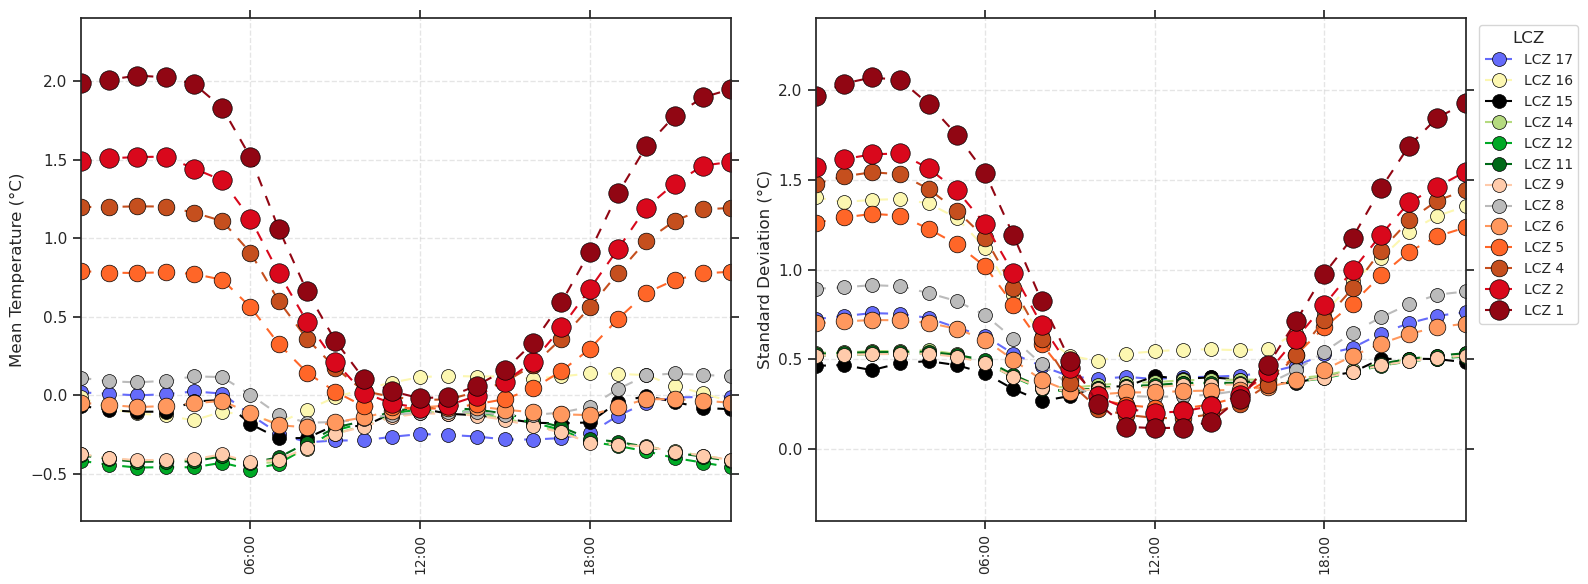

In [27]:
plot_24h_matplot(source=df_combined_24h_HUMIDEX_DT, parameter="HUMIDEX_DT")

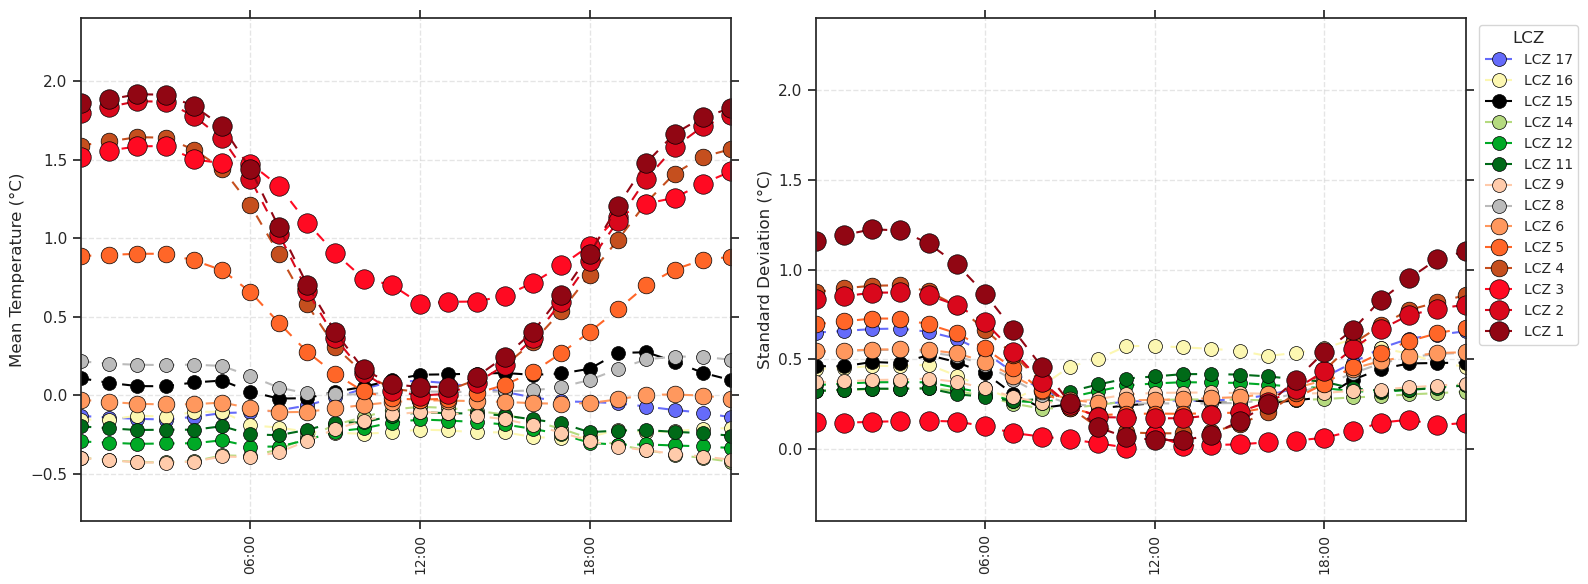

In [28]:
plot_24h_matplot(source=df_combined_24h_HOSTRADA_DT, parameter="HOSTRADA_DT")

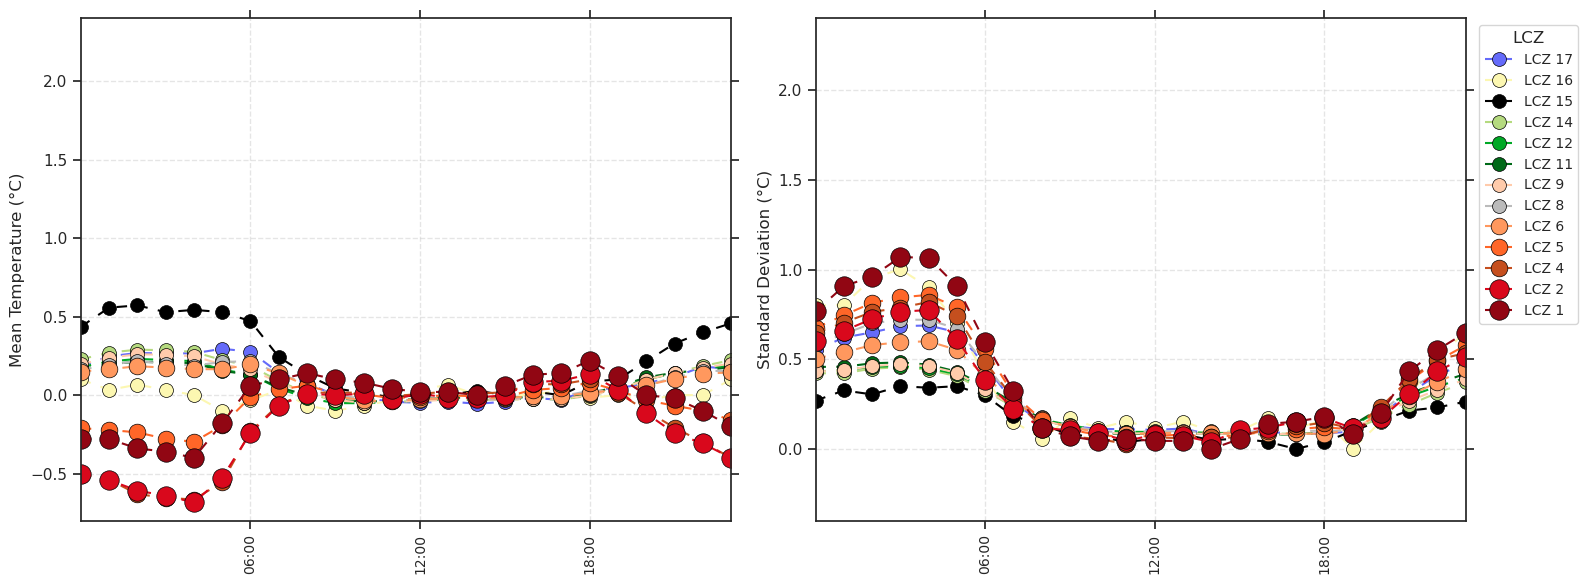

In [29]:
plot_24h_matplot(source=df_combined_24h_Heat_Index_DT, parameter="Heat_Index_DT")

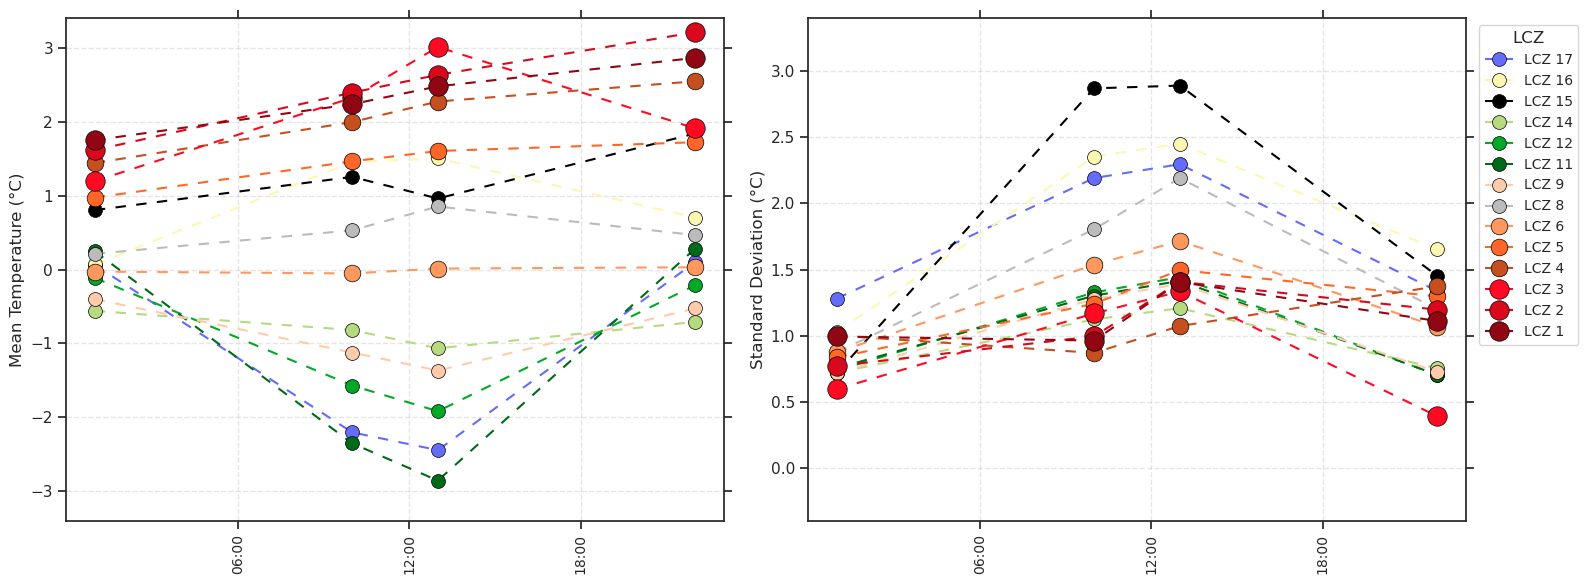

In [17]:
df_LST_time  = df_combined.iloc[:,0:4].rename(columns={"LST_01": "01:00", "LST_10": "10:00","LST_13": "13:00", "LST_22": "22:00"})
df_LST_time = df_LST_time.reset_index().melt(id_vars='location', var_name='Column', value_name='Temperature')
df_LST_time = df_LST_time.merge(df_combined, on="location")

plot_24h_matplot(source=df_LST_time, parameter="LST_DT")

## Correlation

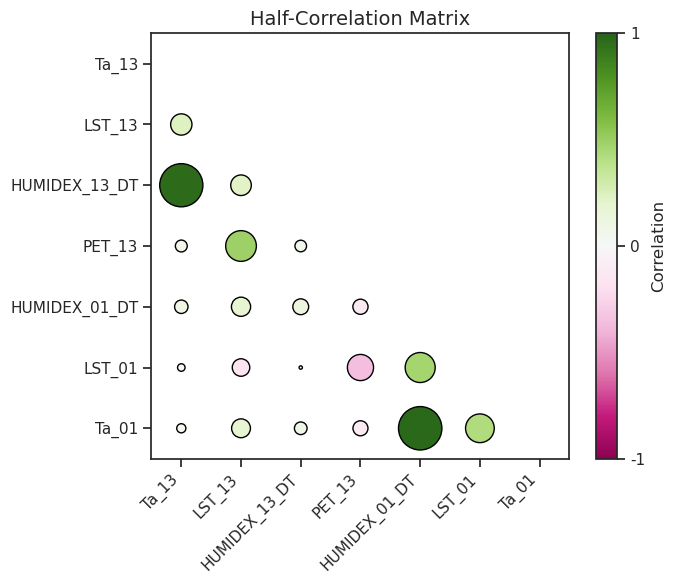

In [111]:
# Compute the correlation matrix
df_data = df_combined[['Ta_13', 'LST_13', 'HUMIDEX_13_DT', 'PET_13', 'HUMIDEX_01_DT', 'LST_01', 'Ta_01']]
corr = df_data.corr()

# Create the half-mask for the lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Get matrix size
n_vars = corr.shape[0]
x, y = np.meshgrid(np.arange(n_vars), np.arange(n_vars))

# Filter for lower triangle
x, y = x[~mask], y[~mask]  # Get indices of lower triangle
values = corr.values[~mask]  # Extract corresponding correlation values

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter plot with color and size based on correlation
scatter = ax.scatter(
    x, y, s=np.abs(values) * 1000, c=values, cmap='PiYG', edgecolor='black', vmin=-1, vmax=1
)

# Add color bar with correct range
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', label="Correlation")
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['-1', '0', '1'])

# Customize plot
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_xlim(-0.5, n_vars - 0.5)
ax.set_ylim(-0.5, n_vars - 0.5)
ax.invert_yaxis()  # Match heatmap orientation
ax.set_title("Half-Correlation Matrix", fontsize=14)

# Adjust layout
plt.tight_layout()

# Show the plot
fig.savefig("figures/figure_05_correlation.png", format='png', bbox_inches='tight')

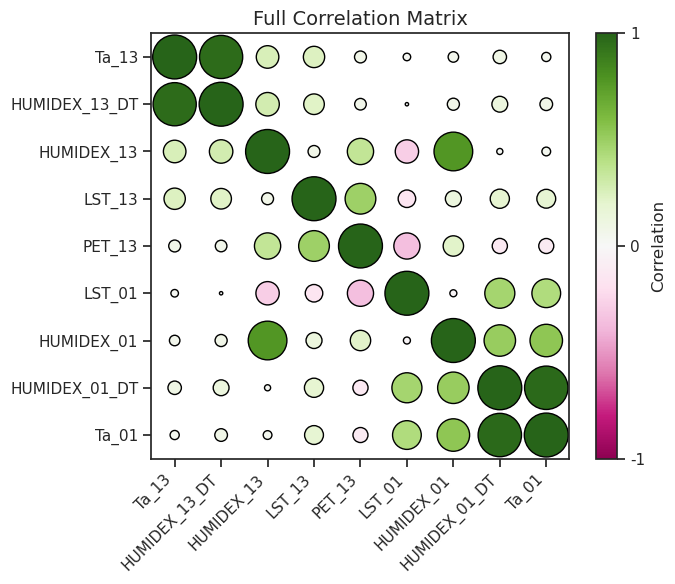

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the correlation matrix
df_data = df_combined[['Ta_13','HUMIDEX_13_DT',  'HUMIDEX_13','LST_13', 'PET_13',  'LST_01', 'HUMIDEX_01','HUMIDEX_01_DT','Ta_01']]
corr = df_data.corr()

# Get matrix size
n_vars = corr.shape[0]
x, y = np.meshgrid(np.arange(n_vars), np.arange(n_vars))

# Extract corresponding correlation values
values = corr.values.flatten()

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

# Scatter plot with color and size based on correlation
scatter = ax.scatter(
    x.flatten(), y.flatten(), s=np.abs(values) * 1000, c=values, cmap='PiYG', edgecolor='black', vmin=-1, vmax=1
)

# Add color bar with correct range
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', label="Correlation")
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['-1', '0', '1'])

# Customize plot
ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_xlim(-0.5, n_vars - 0.5)
ax.set_ylim(-0.5, n_vars - 0.5)
ax.invert_yaxis()  # Match heatmap orientation
ax.set_title("Full Correlation Matrix", fontsize=14)

# Adjust layout
plt.tight_layout()

# Show plot
#plt.show()
fig.savefig("figures/figure_05_correlation_full.png", format='png', bbox_inches='tight')


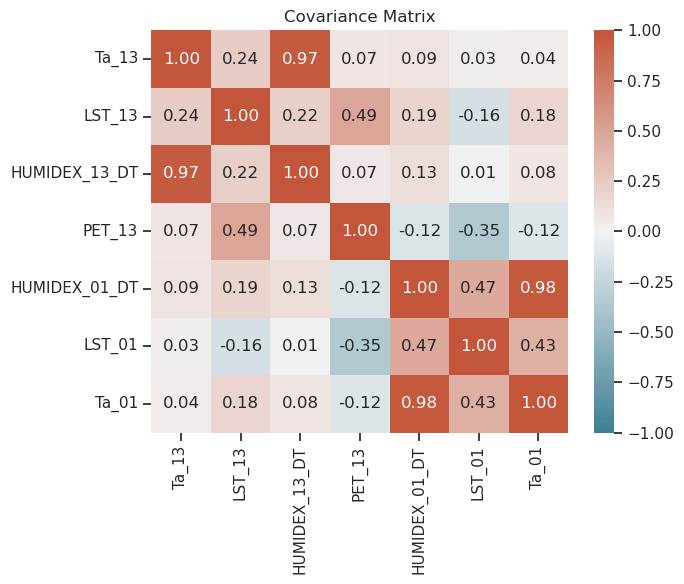

In [101]:
df_data = df_combined[[ 'Ta_13','LST_13', 'HUMIDEX_13_DT', 'PET_13','HUMIDEX_01_DT','LST_01', 'Ta_01']]
cov = df_data.corr()

plt.figure(figsize=(7, 6))
test = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(cov, annot=True, cmap=test, fmt=".2f", vmin=-1, vmax=1)

# Set the title and adjust plot layout
plt.title("Covariance Matrix")
plt.tight_layout()

# Show the plot
plt.show()
#plt.savefig(path_data_old+'hesse-uhi/paper/plots/corr_all.png', bbox_inches='tight', dpi=300)

'    \nfor df in list_df_corr_all:\n    fig = plt.figure()\n    \n    plt.scatter(df["LCZ"],df["Ta_01"], label="Ta 01:00", color="darkblue", alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["HUMIDEX_01_DT"], label="HUMIDEX 01:00", color="darkblue", marker=\'x\', alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["LST_01"], label="LST 01:00", color="darkblue", marker=\'P\', alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["Ta_13"], label="Ta 13:00", color="darkorange", alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["HUMIDEX_13_DT"], label="HUMIDEX 13:00", color="darkorange", marker=\'x\', alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["LST_13"], label="LST 13:00", color="darkorange", marker=\'P\', alpha=0.7, s=100)\n    plt.scatter(df["LCZ"],df["PET_13"], label="PET 13:00", color="darkorange", marker=\'*\', alpha=0.7, s=100)\n    # Put a legend to the right of the current axis\n    plt.xlabel("LCZ")\n    plt.ylabel("correlation")\n    plt.tick_params(axis=\'both\', which=\'both\', directio

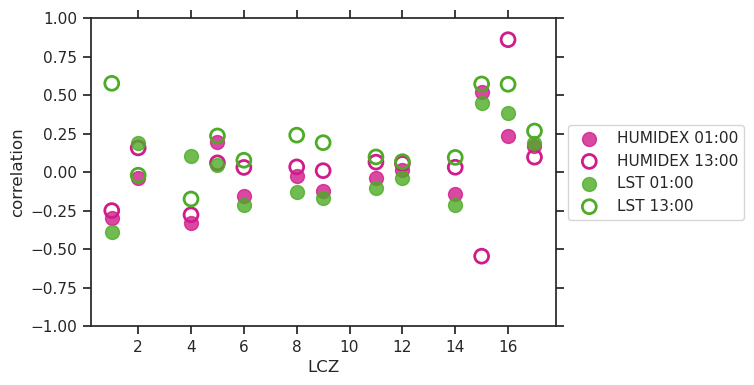

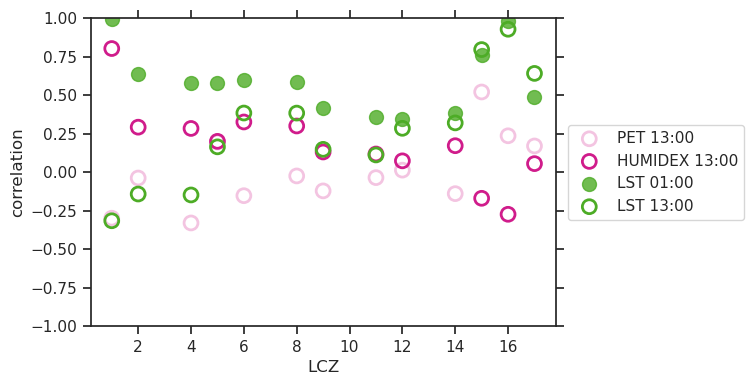

In [74]:
# Group by 'LCZ' column and iterate over groups
cov_PET_13 = []
cov_Ta_13 = []
cov_LST_13 = []
cov_HUMIDEX_13 = []
cov_Ta_01 = []
cov_LST_01 = []
cov_HUMIDEX_01 = []


for group, data in df_combined.groupby('LCZ'):
    df_data = data[[ 'Ta_13','LST_13', 'HUMIDEX_13_DT', 'PET_13','HUMIDEX_01_DT','LST_01', 'Ta_01']]
    cov = df_data.corr()

    df = pd.DataFrame(cov["PET_13"]).T
    df["LCZ"]=group
    cov_PET_13.append(df)

    df = pd.DataFrame(cov["Ta_13"]).T
    df["LCZ"]=group
    cov_Ta_13.append(df)

    df=pd.DataFrame(cov["LST_13"]).T
    df["LCZ"]=group
    cov_LST_13.append(df)

    df = pd.DataFrame(cov["HUMIDEX_13_DT"]).T
    df["LCZ"]=group
    cov_HUMIDEX_13.append(df)

    df = pd.DataFrame(cov["Ta_01"]).T
    df["LCZ"]=group
    cov_Ta_01.append(df)

    df = pd.DataFrame(cov["LST_01"]).T
    df["LCZ"]=group
    cov_LST_01.append(df)

    df = pd.DataFrame(cov["HUMIDEX_01_DT"]).T
    df["LCZ"]=group
    cov_HUMIDEX_01.append(df)

    # Create the heatmap
    #plt.figure(figsize=(12, 10))
    #test = sns.diverging_palette(220, 20, as_cmap=True)
    #sns.heatmap(cov, annot=True, cmap=test, fmt=".2f", vmin=-1, vmax=1)

    # Set the title and adjust plot layout
    #plt.title(f"Covariance Matrix - LCZ {group}")
    #plt.tight_layout()

    # Show the plot
    # plt.show()

df_corr_PET = pd.concat(cov_PET_13, ignore_index=True)
df_corr_Ta_13 = pd.concat(cov_Ta_13, ignore_index=True)
df_corr_Ta_01 = pd.concat(cov_Ta_01, ignore_index=True)
df_corr_LST_13 = pd.concat(cov_LST_13, ignore_index=True)
df_corr_LST_01 = pd.concat(cov_LST_01, ignore_index=True)
df_corr_HUMIDEX_13 = pd.concat(cov_HUMIDEX_13, ignore_index=True)
df_corr_HUMIDEX_01 = pd.concat(cov_HUMIDEX_01, ignore_index=True)

list_df_corr_all = [df_corr_PET,df_corr_Ta_13,df_corr_Ta_01,df_corr_LST_13,df_corr_LST_01,df_corr_HUMIDEX_13,df_corr_HUMIDEX_01]
list_names = ["PET 13:00","Ta 13:00","Ta 01:00","LST 13:00","LST 01:00","HUMIDEX 13:00","HUMIDEX 01:00"]

counter = 0

list_names = ["PET", "HUMIDEX"]
for df in [df_corr_PET, df_corr_HUMIDEX_01]:
    fig = plt.figure(figsize=(6, 4))

    df = df[df['LCZ'] != 3] # only one datapoint: print(len(df[df['LCZ'] == 3]))

    if list_names[counter] == "PET":
    
        #plt.scatter(df["LCZ"],df["Ta_01"], label="Ta 01:00", color="darkorange", alpha=0.8, s=100)
        #plt.scatter(df["LCZ"],df["Ta_13"], label="Ta 13:00", color="darkorange",marker='o', facecolors='none', linewidths=2, s=100)
       
        plt.scatter(df["LCZ"],df["HUMIDEX_01_DT"], label="HUMIDEX 01:00", color="#d01c8b", alpha=0.8, s=100)
        plt.scatter(df["LCZ"],df["HUMIDEX_13_DT"], label="HUMIDEX 13:00", color="#d01c8b", marker='o', facecolors='none', linewidths=2, s=100)
        
        plt.scatter(df["LCZ"],df["LST_01"], label="LST 01:00", color="#4dac26",  alpha=0.8, s=100)
        plt.scatter(df["LCZ"],df["LST_13"], label="LST 13:00", color="#4dac26", marker='o', facecolors='none', linewidths=2, s=100)
        
    #plt.scatter(df["LCZ"],df["PET_13"], label="PET 13:00", color="darkorange", marker='*', alpha=0.7, s=100)
    else:
        #plt.scatter(df["LCZ"],df["Ta_01"], label="Ta 01:00", color="darkorange", alpha=0.8, s=100)
        #plt.scatter(df["LCZ"],df["Ta_13"], label="Ta 13:00", color="darkorange",marker='o', facecolors='none', linewidths=2, s=100)

        plt.scatter(df["LCZ"],df["PET_13"], label="PET 13:00", color="#f1b6da", alpha=0.8,  s=100, marker='o', facecolors='none', linewidths=2, )
  
        # plt.scatter(df["LCZ"],df["HUMIDEX_01_DT"], label="HUMIDEX 01:00", color="darkorange", alpha=0.8, s=100)
        plt.scatter(df["LCZ"],df["HUMIDEX_13_DT"], label="HUMIDEX 13:00", color="#d01c8b", marker='o', facecolors='none', linewidths=2, s=100)
        
        plt.scatter(df["LCZ"],df["LST_01"], label="LST 01:00", color="#4dac26",  alpha=0.8, s=100)
        plt.scatter(df["LCZ"],df["LST_13"], label="LST 13:00", color="#4dac26", marker='o', facecolors='none', linewidths=2, s=100)
        
  
    # Put a legend to the right of the current axis
    plt.xlabel("LCZ")
    plt.ylabel("correlation")
    plt.ylim([-1,1])
    plt.tick_params(axis='both', which='both', direction='out', top=True, right=True)

    #plt.title(list_names[counter])
    plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
    #plt.legend()
    
    #plt.show()
    plt.savefig('figures/corr_all_LCZ_'+list_names[counter].replace(" ","_").replace(":","-")+'.svg', bbox_inches='tight', dpi=300)
    #plt.close()
    counter = counter +1
"""    
for df in list_df_corr_all:
    fig = plt.figure()
    
    plt.scatter(df["LCZ"],df["Ta_01"], label="Ta 01:00", color="darkblue", alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["HUMIDEX_01_DT"], label="HUMIDEX 01:00", color="darkblue", marker='x', alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["LST_01"], label="LST 01:00", color="darkblue", marker='P', alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["Ta_13"], label="Ta 13:00", color="darkorange", alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["HUMIDEX_13_DT"], label="HUMIDEX 13:00", color="darkorange", marker='x', alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["LST_13"], label="LST 13:00", color="darkorange", marker='P', alpha=0.7, s=100)
    plt.scatter(df["LCZ"],df["PET_13"], label="PET 13:00", color="darkorange", marker='*', alpha=0.7, s=100)
    # Put a legend to the right of the current axis
    plt.xlabel("LCZ")
    plt.ylabel("correlation")
    plt.tick_params(axis='both', which='both', direction='out', top=True, right=True)
    

    plt.title(list_names[counter])
    plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
    #plt.legend()
    
    plt.show()
    #plt.savefig(path_data_old+'hesse-uhi/paper/plots/corr_all_LCZ_'+list_names[counter].replace(" ","_").replace(":","-")+'.png', bbox_inches='tight', dpi=300)
    plt.close()
    counter = counter +1
"""